# A Systemic Risk Framework for the Vietnamese Market: a Composite Risk Index and Financial Stress Prediction

## 1. Collect the Data

Import the needed libraries.

In [1]:
import requests
import pandas as pd
from functools import reduce
import io
import time
import yfinance as yf
try:
  import akshare as ak
except:
  !pip install akshare
  import akshare as ak
from concurrent.futures import ThreadPoolExecutor, as_completed
from google.colab import drive
from google.colab import files
import os

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 48.4 MB/s eta 0:00:00
  Created wheel for jsonpath: filename=jsonpath-0.82.2-py3-none-any.whl size=5615 sha256=918233e9e88d8ae4524ee5aafc57110b54922a01a2e4ffb0d07e9c49f0845b2d
  Stored in directory: /root/.cache/pip/wheels/73/76/e2/980a29341fe37a583ada29594ed529708d5e8e2c0f9d97c3cc
Successfully built jsonpath


Build a Data Information Table for the Vietnamese equity data, including:
- Ticker;
- Company Name;
- Sector: the industry the company operates in;
- Exchange;
- Risk Transmission Channel: a macro-economic sector that represents a specific source or amplifier of shocks, spreading systemic risk within and across sectors.

In [2]:
ticker_info = {
    "NT2": {"Risk Transmission Channel": "Energy & Infrastructure", "Sector": "Energy", "Company": "PetroVietnam Power Nhon Trach 2 JSC", "Exchange": "HOSE"},
    "PVD": {"Risk Transmission Channel": "Energy & Infrastructure", "Sector": "Energy", "Company": "PetroVietnam Drilling & Well Services Corp", "Exchange":"HOSE"},
    "PVS": {"Risk Transmission Channel": "Energy & Infrastructure", "Sector": "Energy", "Company": "PetroVietnam Technical Services Corp", "Exchange": "HNX"},
    "PVT": {"Risk Transmission Channel": "Energy & Infrastructure", "Sector": "Energy", "Company": "PetroVietnam Transportation Corp", "Exchange":"HOSE"},
    "REE": {"Risk Transmission Channel": "Energy & Infrastructure", "Sector": "Utilities / Infrastructure", "Company": "Refrigeration Electrical Engineering Corp", "Exchange":"HOSE"},
    "ACB": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Banking", "Company": "Asia Commercial Joint Stock Bank", "Exchange":"HOSE"},
    "CTG": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Banking", "Company": "VietinBank", "Exchange":"HOSE"},
    "MBB": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Banking", "Company": "Military Commercial JSB (MB Bank)", "Exchange":"HOSE"},
    "SHB": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Banking", "Company": "Saigon-Hanoi Commercial JSB", "Exchange":"HOSE"},
    "STB": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Banking", "Company": "Saigon Thuong Tin Commercial JSB", "Exchange":"HOSE"},
    "VCB": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Banking", "Company": "Vietcombank", "Exchange":"HOSE"},
    "BVH": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Insurance", "Company": "Bao Viet Holdings", "Exchange":"HOSE"},
    "PVI": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Insurance", "Company": "PVI Holdings", "Exchange": "HNX"},
    "SSI": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Securities/Brokerage", "Company": "SSI Securities Corp", "Exchange":"HOSE"},
    "VIX": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Securities/Brokerage", "Company": "VIX Securities JSC", "Exchange":"HOSE"},
    "VND": {"Risk Transmission Channel": "Financial System", "Sector": "Finance - Securities/Brokerage", "Company": "VNDirect Securities Corp", "Exchange":"HOSE"},
    "GMD": {"Risk Transmission Channel": "Logistics", "Sector": "Logistics", "Company": "Gemadept Corp", "Exchange":"HOSE"},
    "VSC": {"Risk Transmission Channel": "Logistics", "Sector": "Logistics", "Company": "Vietnam Container Shipping JSC", "Exchange":"HOSE"},
    "MSN": {"Risk Transmission Channel": "Real Economy", "Sector": "Consumer Goods / Retail", "Company": "Masan Group Corp", "Exchange":"HOSE"},
    "PNJ": {"Risk Transmission Channel": "Real Economy", "Sector": "Consumer Goods / Retail", "Company": "Phu Nhuan Jewelry JSC", "Exchange":"HOSE"},
    "VNM": {"Risk Transmission Channel": "Real Economy", "Sector": "Consumer Goods / Retail", "Company": "Vietnam Dairy Products JSC", "Exchange":"HOSE"},
    "CSM": {"Risk Transmission Channel": "Real Economy", "Sector": "Industrial / Materials", "Company": "Casumina", "Exchange":"HOSE"},
    "DPM": {"Risk Transmission Channel": "Real Economy", "Sector": "Industrial / Materials", "Company": "PetroVietnam Fertilizer and Chemicals Corp", "Exchange":"HOSE"},
    "HPG": {"Risk Transmission Channel": "Real Economy", "Sector": "Industrial / Materials", "Company": "Hoa Phat Group JSC", "Exchange":"HOSE"},
    "HSG": {"Risk Transmission Channel": "Real Economy", "Sector": "Industrial / Materials", "Company": "Hoa Sen Group", "Exchange":"HOSE"},
    "NKG": {"Risk Transmission Channel": "Real Economy", "Sector": "Industrial / Materials", "Company": "Nam Kim Steel JSC", "Exchange":"HOSE"},
    "FPT": {"Risk Transmission Channel": "Real Economy", "Sector": "Technology", "Company": "FPT Corp", "Exchange":"HOSE"},
    "DIG": {"Risk Transmission Channel": "Real Estate", "Sector": "Real Estate", "Company": "Development Investment Construction JSC", "Exchange":"HOSE"},
    "DXG": {"Risk Transmission Channel": "Real Estate", "Sector": "Real Estate", "Company": "Dat Xanh Group JSC", "Exchange":"HOSE"},
    "KBC": {"Risk Transmission Channel": "Real Estate", "Sector": "Real Estate", "Company": "Kinh Bac City Development Holding Corp", "Exchange":"HOSE"},
    "KDH": {"Risk Transmission Channel": "Real Estate", "Sector": "Real Estate", "Company": "Khang Dien House Trading and Investment JSC", "Exchange":"HOSE"},
    "VIC": {"Risk Transmission Channel": "Real Estate", "Sector": "Real Estate", "Company": "Vingroup JSC", "Exchange":"HOSE"},
}
ticker_df = (
    pd.DataFrame.from_dict(ticker_info, orient="index")
      .reset_index()
      .rename(columns={"index": "Ticker"})
      [["Ticker", "Company", "Sector", "Exchange", "Risk Transmission Channel"]]
)

ticker_df.sort_values(["Risk Transmission Channel", "Sector", "Company", "Ticker"],ignore_index=True)

,Ticker,Company,Sector,Exchange,Risk Transmission Channel
0,PVD,PetroVietnam Drilling & Well Services Corp,Energy,HOSE,Energy & Infrastructure
1,NT2,PetroVietnam Power Nhon Trach 2 JSC,Energy,HOSE,Energy & Infrastructure
2,PVS,PetroVietnam Technical Services Corp,Energy,HNX,Energy & Infrastructure
3,PVT,PetroVietnam Transportation Corp,Energy,HOSE,Energy & Infrastructure
4,REE,Refrigeration Electrical Engineering Corp,Utilities / Infrastructure,HOSE,Energy & Infrastructure
5,ACB,Asia Commercial Joint Stock Bank,Finance - Banking,HOSE,Financial System
6,MBB,Military Commercial JSB (MB Bank),Finance - Banking,HOSE,Financial System
7,STB,Saigon Thuong Tin Commercial JSB,Finance - Banking,HOSE,Financial System
8,SHB,Saigon-Hanoi Commercial JSB,Finance - Banking,HOSE,Financial System
9,VCB,Vietcombank,Finance - Banking,HOSE,Financial System


Build a function to collect Vietnamese stock data from <a href='https://cafef.vn/'>CafeF</a>.

In [3]:
session = requests.Session()
headers = {"User-Agent": "Mozilla/5.0", "Referer": "https://cafef.vn/", "Origin": "https://cafef.vn", "X-Requested-With": "XMLHttpRequest",}

def fetch_price_history_cafef(ticker, start="2012-01-01", end="2026-03-31"):
  url = "https://cafef.vn/du-lieu/Ajax/PageNew/DataHistory/PriceHistory.ashx"

  all_data = []
  page = 1

  while True:
    params = {"Symbol":ticker,"StartDate":"","EndDate":"","PageIndex":page,"PageSize":100}

    try:
      r = session.get(url, headers=headers, params=params, timeout=15)
      r.raise_for_status()
      json_data = r.json()
    except Exception as e:
      print(f"{ticker}: request failed -> {e}")
      break

    if not json_data or json_data.get("Data") is None:
      print(f"{ticker}: no data returned (page {page})")
      break

    data = json_data["Data"].get("Data", [])

    if not data:
      break

    all_data.extend(data)

    # stop if last page
    if len(data) < 100:
      break

    page += 1
    time.sleep(0.1)  # avoid throttling

  if not all_data:
    print(f"{ticker}: EMPTY")
    return pd.DataFrame(columns=["Date", f"{ticker}_close", f"{ticker}_volume"])

  df = pd.DataFrame(all_data).rename(columns={"Ngay": "Date","GiaDieuChinh": f"{ticker}_close","KhoiLuongKhopLenh": f"{ticker}_volume"})

  df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
  df[f"{ticker}_close"] = pd.to_numeric(df[f"{ticker}_close"], errors="coerce")
  df[f"{ticker}_volume"] = pd.to_numeric(df[f"{ticker}_volume"], errors="coerce")
  start_dt = pd.to_datetime(start, format="%Y-%m-%d")
  end_dt = pd.to_datetime(end, format="%Y-%m-%d")
  df = df[(df["Date"] >= start_dt) & (df["Date"] <= end_dt)]

  return df[["Date", f"{ticker}_close", f"{ticker}_volume"]]

Collect the Vietnamese equity data from <a href='https://cafef.vn/'>CafeF.</a>

```python
def fetch_wrapper(t):
    print(f"Fetching {t}...")
    df = fetch_price_history_cafef(t)
    return t, df

dfs = []

with ThreadPoolExecutor(max_workers=5) as executor:
    futures = [executor.submit(fetch_wrapper, t) for t in ticker_info.keys()]

    for future in as_completed(futures):
        t, df = future.result()
        if not df.empty:
            dfs.append(df)
        else:
            print(f"{t}: dropped")
```
Fetching NT2...  
Fetching PVD...  
Fetching PVS...  
Fetching PVT...  
Fetching REE...  
Fetching ACB...  
Fetching CTG...  
Fetching MBB...  
Fetching SHB...  
Fetching STB...  
Fetching VCB...  
Fetching BVH...  
Fetching PVI...  
Fetching SSI...  
Fetching VIX...  
Fetching VND...  
Fetching GMD...  
Fetching VSC...  
Fetching MSN...  
Fetching PNJ...  
Fetching VNM...  
Fetching CSM...  
Fetching DPM...  
Fetching HPG...  
Fetching HSG...  
Fetching NKG...  
Fetching FPT...  
Fetching DIG...  
Fetching DXG...  
Fetching KBC...  
Fetching KDH...  
Fetching VIC...  

Save the dataframe to avoid fetching the data from <a href='https://cafef.vn/'>CafeF</a> again.

```python
df_vn = reduce(lambda left, right: pd.merge(left, right, on="Date", how="outer"),dfs)
df_vn = df_vn.sort_values("Date").reset_index(drop=True)
df_vn.to_csv("df_vn.csv", index=False)  # saves in VM
files.download("df_vn.csv")
df_vn.to_parquet("df_vn.parquet", index=False)
files.download("df_vn.parquet")
```

Import the dataframe (parquet) to the notebook.

In [4]:
file_path = "/content/drive/My Drive/WQU/10_Capstone_Project/Capstone Project/data/df_vn.csv"
def import_data(file_path):
  try:
    drive.mount('/content/drive', force_remount=True)
    # Check if file exists
    if os.path.exists(file_path):
      df = pd.read_parquet(file_path)
      print(f"Loaded dataframe from Drive ({file_path})")
    else:
      raise FileNotFoundError(f"File not found at {file_path}")

  except Exception as e:
    print(f"Drive not available or file missing: {e}")
    print("Please upload dataframe manually.")
    uploaded = files.upload()

    # Automatically read the uploaded file
    file_name = list(uploaded.keys())[0]  # pick the first uploaded file
    try:
      df = pd.read_parquet(io.BytesIO(uploaded[file_name]))
    except:
      print("Wrong file extension. Parquet file required.")
    print(f"Loaded {file_name} from manual upload.")
    return df

In [5]:
df_vn = import_data(file_path)

Drive not available or file missing: Error: credential propagation was unsuccessful
Please upload dataframe manually.


Saving df_vn.parquet to df_vn.parquet
Loaded df_vn.parquet from manual upload.


In [6]:
df_vn.head()

,Date,NT2_close,NT2_volume,PVT_close,PVT_volume,PVS_close,PVS_volume,PVD_close,PVD_volume,REE_close,...,DIG_close,DIG_volume,DXG_close,DXG_volume,KBC_close,KBC_volume,KDH_close,KDH_volume,VIC_close,VIC_volume
0,2012-01-03,1.06,16500.0,1.01,33120.0,3.73,77900.0,13.42,40680.0,2.77,...,2.04,105040.0,1.17,30690.0,4.96,315520.0,3.60,55300.0,7.81,39190.0
1,2012-01-04,1.06,12000.0,1.04,457630.0,3.50,285700.0,12.79,97220.0,2.85,...,2.00,142770.0,1.15,28520.0,5.01,70540.0,3.73,61980.0,7.85,38760.0
2,2012-01-05,0.97,0.0,1.07,621160.0,3.42,446500.0,12.74,66780.0,2.85,...,1.96,66330.0,1.13,33310.0,4.91,43340.0,3.90,52010.0,7.49,15860.0
3,2012-01-06,1.06,2900.0,1.04,282320.0,3.34,94100.0,12.74,15050.0,2.80,...,1.91,242390.0,1.12,13890.0,4.91,29410.0,3.86,37940.0,7.45,22080.0
4,2012-01-09,1.10,1100.0,1.04,231330.0,3.29,125400.0,12.58,31050.0,2.90,...,1.85,630070.0,1.10,6770.0,4.82,59880.0,3.81,53980.0,7.81,14940.0


In [7]:
df_vn.tail()

,Date,NT2_close,NT2_volume,PVT_close,PVT_volume,PVS_close,PVS_volume,PVD_close,PVD_volume,REE_close,...,DIG_close,DIG_volume,DXG_close,DXG_volume,KBC_close,KBC_volume,KDH_close,KDH_volume,VIC_close,VIC_volume
3546,2026-03-25,27.70,2979600.0,21.70,8810800.0,42.2,7282100.0,34.75,3336600.0,70.9,...,13.80,11696900.0,14.15,20550300.0,28.9,4274000.0,25.85,5073300.0,128.7,3013400.0
3547,2026-03-26,27.75,1455700.0,22.40,13267800.0,42.0,5057500.0,34.70,4219300.0,71.7,...,13.55,8624500.0,13.85,15497700.0,28.7,1780000.0,25.45,2692100.0,130.0,2435600.0
3548,2026-03-27,27.90,950600.0,22.30,9317400.0,42.8,5938400.0,35.75,5186400.0,71.7,...,14.45,24713800.0,14.60,41747300.0,30.7,6091600.0,26.40,4704200.0,132.6,2124700.0
3549,2026-03-30,27.90,1371700.0,21.85,12201400.0,42.8,5262900.0,36.20,4041300.0,70.0,...,14.20,13413500.0,14.30,16998400.0,31.8,7130700.0,26.05,4370900.0,129.5,2042500.0
3550,2026-03-31,27.60,846800.0,21.80,7238400.0,40.9,7568200.0,34.80,5738900.0,68.5,...,14.25,11416400.0,14.55,21018600.0,31.9,2270100.0,26.00,4193600.0,135.0,3316700.0


In [8]:
df_vn.shape

(3551, 65)

In [9]:
df_vn.index.has_duplicates

False

___

Gather VN-Index historical data (source: <a href='https://cafef.vn/'>CafeF</a>).

```python
df_vnindex = fetch_price_history_cafef("VNINDEX", start="2012-01-01", end="2026-03-31")
df_vnindex = df_vnindex.sort_values("Date").reset_index(drop=True)
```

Collect data for external financial markets: advanced and regionally dominant economies (sources: <a href='https://finance.yahoo.com/'>Yahoo Finance</a> and <a href='https://github.com/akfamily/akshare'>AKShare</a>).

```python
foreign_index = {
    "^GSPC": "S&P 500 (US)",
    "^GSPTSE": "S&P/TSX (Canada)",
    "^STOXX50E": "EURO STOXX 50 (EU)",
    "^FTSE": "FTSE 100 (UK)",
    # "000300.SS": "CSI 300 (China)",
    "^N225": "Nikkei 225 (Japan)",
    "^KS11": "KOSPI (S.Korea)",
    "^AXJO": "S&P/ASX 200 (Australia)",
    "^HSI": "Hang Seng (HK)",
    "^TWII": "TWSE (Taiwan)"
}
foreign_index.keys()
df_fx = yf.download(list(foreign_index.keys()), start="2012-01-01", end="2026-04-01", auto_adjust= True)[['Close']]#, 'Volume']]

df_fx.columns =  [f"{ticker}_{level}" for level, ticker in df_fx.columns]
```

```python
df_CSI300= (
    ak.stock_zh_index_daily(symbol="sh000300")
      .assign(date=lambda x: pd.to_datetime(x["date"]))
      .set_index("date")
      .loc["2012-01-01":"2026-03-31", ["close"]]#, "volume"]]
      .rename_axis(None)
      .rename(columns={"close": "CSI300_close"})#, "volume": "CSI300_volume"})
      .reset_index()
      .rename(columns={"index": "Date", "date": "Date"})
      .set_index("Date")
)
```

```python
# combine all international data
df_glob = (df_vnindex.merge(df_fx, on="Date", how="outer").merge(df_CSI300, on="Date", how="outer").sort_values("Date").reset_index(drop=True)).drop(['VNINDEX_volume'], axis=1)
```

Save the dataframe with the international indexes on the Drive.

```python
df_glob.to_csv("df_glob.csv", index=False)
files.download("df_glob.csv")
df_glob.to_parquet("df_glob.parquet", index=False)
files.download("df_glob.parquet")
```

Import the dataframe with the international data to the notebook.

In [10]:
file_path = "/content/drive/My Drive/WQU/10_Capstone_Project/Capstone Project/data/df_glob.csv"
df_glob = import_data(file_path)

Drive not available or file missing: Error: credential propagation was unsuccessful
Please upload dataframe manually.


Saving df_glob.parquet to df_glob.parquet
Loaded df_glob.parquet from manual upload.


In [11]:
df_glob.head()

,Date,VNINDEX_close,^AXJO_Close,^FTSE_Close,^GSPC_Close,^GSPTSE_Close,^HSI_Close,^KS11_Close,^N225_Close,^STOXX50E_Close,^TWII_Close,CSI300_close
0,2012-01-02,NaN,NaN,NaN,NaN,NaN,NaN,1826.369995,NaN,NaN,NaN,NaN
1,2012-01-03,350.00,4101.200195,5699.899902,1277.060059,12208.400391,18877.410156,1875.410034,NaN,2389.909912,7053.348145,NaN
2,2012-01-04,348.84,4187.799805,5668.500000,1277.300049,12226.500000,18727.310547,1866.219971,8560.110352,2349.889893,7082.937988,2298.753
3,2012-01-05,340.94,4142.700195,5624.299805,1281.060059,12237.400391,18813.410156,1863.739990,8488.709961,2315.750000,7130.827148,2276.385
4,2012-01-06,336.73,4108.500000,5649.700195,1277.810059,12188.599609,18593.060547,1843.140015,8390.349609,2298.649902,7120.477051,2290.601


In [12]:
df_glob.tail()

,Date,VNINDEX_close,^AXJO_Close,^FTSE_Close,^GSPC_Close,^GSPTSE_Close,^HSI_Close,^KS11_Close,^N225_Close,^STOXX50E_Close,^TWII_Close,CSI300_close
3701,2026-03-25,1658.19,8557.599609,10106.799805,6591.899902,32382.599609,25335.949219,5642.209961,53749.621094,5649.330078,33439.109375,4537.466
3702,2026-03-26,1644.63,8525.700195,9972.200195,6477.160156,31887.500000,24856.429688,5460.459961,53603.648438,5565.930176,33337.621094,4477.534
3703,2026-03-27,1672.80,8516.299805,9967.400391,6368.850098,31960.699219,24951.880859,5438.870117,53373.070312,5505.799805,33112.589844,4502.570
3704,2026-03-30,1662.54,8461.000000,10128.000000,6343.720215,31934.900391,24750.789062,5277.299805,51885.851562,5541.790039,32518.160156,4491.950
3705,2026-03-31,1674.49,8481.799805,10176.500000,6528.520020,32768.000000,24788.140625,5052.459961,51063.718750,5569.729980,31722.990234,4450.049


In [13]:
df_glob.shape

(3706, 12)

## 2. Data Cleaning and Exploratory Data Analysis (EDA)

In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
try:
  from arch.unitroot import ADF
except:
  !pip install arch
  from arch.unitroot import ADF

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 7.6 MB/s eta 0:00:00


### 2.1. Domestic Data

From the dataframe with the Vietnamese equity data, we build 2 separate datasets:
- Daily adjused close prices (currency = VND)
- Daily trading volumes (amount of shares)

In [15]:
# Create a dataframe with the closing prices and with date column as index
df_vn_price = df_vn.set_index('Date')[df_vn.columns[df_vn.columns.str.endswith('_close')]]
df_vn_price = df_vn_price*1000 #Cafef Data in thousand VND
df_vn_price

,NT2_close,PVT_close,PVS_close,PVD_close,REE_close,MBB_close,CTG_close,ACB_close,SHB_close,STB_close,...,DPM_close,HPG_close,HSG_close,NKG_close,FPT_close,DIG_close,DXG_close,KBC_close,KDH_close,VIC_close
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-03,1060.0,1010.0,3730.0,13420.0,2770.0,1350.0,4120.0,2660.0,1050.0,8460.0,...,3400.0,620.0,880.0,1990.0,4040.0,2040.0,1170.0,4960.0,3600.0,7810.0
2012-01-04,1060.0,1040.0,3500.0,12790.0,2850.0,1350.0,4310.0,2700.0,1040.0,8730.0,...,3340.0,610.0,860.0,1910.0,4040.0,2000.0,1150.0,5010.0,3730.0,7850.0
2012-01-05,970.0,1070.0,3420.0,12740.0,2850.0,1320.0,4290.0,2750.0,1020.0,8620.0,...,3290.0,590.0,850.0,1920.0,3950.0,1960.0,1130.0,4910.0,3900.0,7490.0
2012-01-06,1060.0,1040.0,3340.0,12740.0,2800.0,1320.0,4360.0,2740.0,1020.0,8730.0,...,3260.0,570.0,840.0,1940.0,3990.0,1910.0,1120.0,4910.0,3860.0,7450.0
2012-01-09,1100.0,1040.0,3290.0,12580.0,2900.0,1340.0,4390.0,2720.0,1020.0,9160.0,...,3340.0,570.0,860.0,1940.0,4000.0,1850.0,1100.0,4820.0,3810.0,7810.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,27700.0,21700.0,42200.0,34750.0,70900.0,26000.0,34050.0,23800.0,13080.0,62200.0,...,29400.0,26350.0,14400.0,13400.0,77000.0,13800.0,14150.0,28900.0,25850.0,128700.0
2026-03-26,27750.0,22400.0,42000.0,34700.0,71700.0,25800.0,33800.0,23600.0,13210.0,60600.0,...,31100.0,25900.0,14500.0,13350.0,74200.0,13550.0,13850.0,28700.0,25450.0,130000.0
2026-03-27,27900.0,22300.0,42800.0,35750.0,71700.0,26150.0,34800.0,23800.0,13430.0,59900.0,...,30800.0,26500.0,14900.0,13800.0,76100.0,14450.0,14600.0,30700.0,26400.0,132600.0


In [16]:
# Create a dataframe with the trading volumes and with date column as index
df_vn_vol = df_vn.set_index('Date')[df_vn.columns[df_vn.columns.str.endswith('_volume')]]
df_vn_vol

,NT2_volume,PVT_volume,PVS_volume,PVD_volume,REE_volume,MBB_volume,CTG_volume,ACB_volume,SHB_volume,STB_volume,...,DPM_volume,HPG_volume,HSG_volume,NKG_volume,FPT_volume,DIG_volume,DXG_volume,KBC_volume,KDH_volume,VIC_volume
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-03,16500.0,33120.0,77900.0,40680.0,259370.0,462000.0,147320.0,27200.0,384400.0,957240.0,...,215580.0,57960.0,101880.0,6890.0,74810.0,105040.0,30690.0,315520.0,55300.0,39190.0
2012-01-04,12000.0,457630.0,285700.0,97220.0,502250.0,368740.0,294380.0,224200.0,264900.0,2845110.0,...,96730.0,27520.0,110970.0,5100.0,29710.0,142770.0,28520.0,70540.0,61980.0,38760.0
2012-01-05,0.0,621160.0,446500.0,66780.0,407690.0,478490.0,194610.0,344100.0,411200.0,1813900.0,...,186030.0,345840.0,134270.0,4060.0,64890.0,66330.0,33310.0,43340.0,52010.0,15860.0
2012-01-06,2900.0,282320.0,94100.0,15050.0,250620.0,331370.0,330690.0,233100.0,209600.0,3081380.0,...,166820.0,474620.0,245600.0,120860.0,66090.0,242390.0,13890.0,29410.0,37940.0,22080.0
2012-01-09,1100.0,231330.0,125400.0,31050.0,536720.0,464800.0,109050.0,123000.0,517500.0,3524980.0,...,152650.0,187210.0,80650.0,22430.0,46080.0,630070.0,6770.0,59880.0,53980.0,14940.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,2979600.0,8810800.0,7282100.0,3336600.0,3852100.0,13825500.0,6241100.0,12449400.0,76541900.0,5688900.0,...,5732000.0,22967100.0,4120300.0,2834500.0,7429300.0,11696900.0,20550300.0,4274000.0,5073300.0,3013400.0
2026-03-26,1455700.0,13267800.0,5057500.0,4219300.0,2072000.0,13683600.0,5738200.0,8294500.0,67867100.0,5034300.0,...,12313800.0,18424200.0,2034500.0,3367400.0,9743400.0,8624500.0,15497700.0,1780000.0,2692100.0,2435600.0
2026-03-27,950600.0,9317400.0,5938400.0,5186400.0,1678800.0,12866700.0,12073500.0,7638400.0,69844300.0,9368300.0,...,9590700.0,26863700.0,3746700.0,3679600.0,9080300.0,24713800.0,41747300.0,6091600.0,4704200.0,2124700.0


Missing data analysis.

In [17]:
# Check for missing data
for c in df_vn.columns[1:]:
  if c.endswith("close"):
    miss_prc = df_vn[c].isnull().sum()
    print('Missing Price in {} column:'.format(c), miss_prc)

  elif c.endswith("volume"):
    miss_vol = df_vn[c].isnull().sum()
    print('Missing Trading Volume in {} column:'.format(c), miss_vol)
    print('')

Missing Price in NT2_close column: 55
Missing Trading Volume in NT2_volume column: 55

Missing Price in PVT_close column: 2
Missing Trading Volume in PVT_volume column: 2

Missing Price in PVS_close column: 17
Missing Trading Volume in PVS_volume column: 17

Missing Price in PVD_close column: 2
Missing Trading Volume in PVD_volume column: 2

Missing Price in REE_close column: 2
Missing Trading Volume in REE_volume column: 2

Missing Price in MBB_close column: 2
Missing Trading Volume in MBB_volume column: 2

Missing Price in CTG_close column: 2
Missing Trading Volume in CTG_volume column: 2

Missing Price in ACB_close column: 5
Missing Trading Volume in ACB_volume column: 5

Missing Price in SHB_close column: 3
Missing Trading Volume in SHB_volume column: 3

Missing Price in STB_close column: 3
Missing Trading Volume in STB_volume column: 3

Missing Price in VCB_close column: 3
Missing Trading Volume in VCB_volume column: 3

Missing Price in BVH_close column: 2
Missing Trading Volume i

We use 2 approaches for handling missing data:
- Price database: apply forward fill technique to replace NaN values with the last valid observation (no price change on a day the close price is missing).
- Trading Volume database: set missing value to 0 (no trading occurred on a day the trading volume is missing).

In [18]:
# Deal with mising values for Price database: apply NaN Forward fill by propagating the last valid observation to next valid.
df_vn_price.ffill(inplace=True)
# Deal with mising values for Trading Volume database: set missing value to 0.
df_vn_vol = df_vn_vol.fillna(0)

Transform adjusted close price to logarithmic returns and clean header names:  
$r_{t} = ln(\frac{P_{t}}{P_{t-1}})$

In [19]:
# Calculate log returns for Vietnamese stocks
df_vn_ret = np.log(df_vn_price/df_vn_price.shift(1))
df_vn_ret = df_vn_ret.dropna()
df_vn_ret.columns = df_vn_ret.columns.str.replace('_close', '', regex=False)
df_vn_ret

,NT2,PVT,PVS,PVD,REE,MBB,CTG,ACB,SHB,STB,...,DPM,HPG,HSG,NKG,FPT,DIG,DXG,KBC,KDH,VIC
Date,,,,,,,,,,,,,,,,,,,,,
2012-01-04,0.000000,0.029270,-0.063645,-0.048083,0.028472,0.000000,0.045085,0.014926,-0.009569,0.031416,...,-0.017805,-0.016261,-0.022990,-0.041031,0.000000,-0.019803,-0.017242,0.010030,0.035474,0.005109
2012-01-05,-0.088728,0.028438,-0.023122,-0.003917,0.000000,-0.022473,-0.004651,0.018349,-0.019418,-0.012680,...,-0.015083,-0.033336,-0.011696,0.005222,-0.022529,-0.020203,-0.017544,-0.020162,0.044568,-0.046945
2012-01-06,0.088728,-0.028438,-0.023670,0.000000,-0.017700,0.000000,0.016185,-0.003643,0.000000,0.012680,...,-0.009160,-0.034486,-0.011834,0.010363,0.010076,-0.025841,-0.008889,0.000000,-0.010309,-0.005355
2012-01-09,0.037041,0.000000,-0.015083,-0.012638,0.035091,0.015038,0.006857,-0.007326,0.000000,0.048081,...,0.024244,0.000000,0.023530,0.000000,0.002503,-0.031918,-0.018019,-0.018500,-0.013038,0.047191
2012-01-10,0.000000,0.028438,0.006061,0.028988,0.023851,0.014815,0.031393,0.007326,0.028988,0.035392,...,0.023670,0.000000,0.022990,0.000000,0.014889,-0.010870,0.044452,0.028632,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,0.067189,0.023311,0.028848,0.036634,0.067081,0.015504,0.014793,0.029853,0.037388,0.022765,...,0.020619,0.015297,0.003478,0.018833,0.020998,0.021979,0.032319,0.044216,0.033435,0.037203
2026-03-26,0.001803,0.031749,-0.004751,-0.001440,0.011220,-0.007722,-0.007369,-0.008439,0.009890,-0.026060,...,0.056213,-0.017225,0.006920,-0.003738,-0.037041,-0.018282,-0.021429,-0.006944,-0.015595,0.010050
2026-03-27,0.005391,-0.004474,0.018868,0.029811,0.000000,0.013475,0.029157,0.008439,0.016517,-0.011618,...,-0.009693,0.022902,0.027213,0.033152,0.025284,0.064308,0.052736,0.067366,0.036648,0.019803


---

**Vietnamese equity log returns: Exploratory Data Analaysis.**

In [20]:
# EDA: Descriptive Stats for log returns data
df_vn_ret.describe()

,NT2,PVT,PVS,PVD,REE,MBB,CTG,ACB,SHB,STB,...,DPM,HPG,HSG,NKG,FPT,DIG,DXG,KBC,KDH,VIC
count,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,...,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000,3550.000000
mean,0.000918,0.000865,0.000675,0.000268,0.000904,0.000838,0.000599,0.000614,0.000721,0.000562,...,0.000612,0.001062,0.000796,0.000547,0.000822,0.000548,0.000710,0.000524,0.000557,0.000803
std,0.024866,0.024988,0.028172,0.027081,0.019783,0.019565,0.021391,0.017854,0.025394,0.022693,...,0.021161,0.024529,0.031416,0.030785,0.020931,0.029431,0.029677,0.026835,0.021976,0.021631
min,-0.114709,-0.079396,-0.105617,-0.088255,-0.115069,-0.200397,-0.202524,-0.119893,-0.158870,-0.072539,...,-0.073347,-0.289234,-0.470900,-0.285019,-0.237532,-0.092950,-0.145301,-0.073122,-0.220654,-0.308547
25%,-0.008632,-0.012092,-0.012284,-0.013907,-0.008732,-0.007748,-0.009563,-0.006849,-0.012520,-0.010091,...,-0.008969,-0.010000,-0.013355,-0.014096,-0.007283,-0.014676,-0.014884,-0.013023,-0.008196,-0.007402
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.009541,0.013908,0.014064,0.014843,0.009872,0.008934,0.010028,0.007944,0.012195,0.010508,...,0.010328,0.011561,0.014595,0.015020,0.008721,0.016082,0.017271,0.013832,0.008964,0.007644
max,0.119238,0.102195,0.333844,0.153372,0.145147,0.198735,0.221728,0.186218,0.174072,0.134304,...,0.105988,0.356414,0.554311,0.380275,0.227362,0.162768,0.217168,0.364487,0.226854,0.287682


Analysis of central tendency, dispersion and higher moments.

In [21]:
with pd.option_context('display.max_columns', None):
  print(pd.DataFrame({
    'mean': df_vn_ret.mean(),
    'median': df_vn_ret.median(),
    'std': df_vn_ret.std(),
    'skewness': df_vn_ret.skew(),
    'kurtosis': df_vn_ret.kurt()}).T)

               NT2       PVT       PVS       PVD       REE        MBB  \
mean      0.000918  0.000865  0.000675  0.000268  0.000904   0.000838   
median    0.000000  0.000000  0.000000  0.000000  0.000000   0.000000   
std       0.024866  0.024988  0.028172  0.027081  0.019783   0.019565   
skewness  0.139119 -0.005330  0.256079 -0.057371  0.194782   0.080125   
kurtosis  3.786506  1.103268  8.049356  1.092215  5.307337  11.400090   

               CTG       ACB       SHB       STB        VCB       BVH  \
mean      0.000599  0.000614  0.000721  0.000562   0.000739  0.000283   
median    0.000000  0.000000  0.000000  0.000000   0.000000  0.000000   
std       0.021391  0.017854  0.025394  0.022693   0.021569  0.023735   
skewness -0.004440  0.046042  0.163477  0.102228   1.656086  0.035797   
kurtosis  7.570706  8.214922  3.645464  2.038182  58.341368  1.181302   

               PVI        SSI       VIX         VND        VSC        MSN  \
mean      0.000688   0.000691  0.001088    0.

In [22]:
print('Average Skewness-full sample:', df_vn_ret.skew().mean())
print('Average Kurtosis-full sample:', df_vn_ret.kurt().mean())

Average Skewness-full sample: 0.5110215364588894
Average Kurtosis-full sample: 25.52753406022312


Median is 0 for all stocks and the mean is also very close to 0, which means daily returns are centered around 0 with negligible drift.  

Daily volatility is quite high, approximately ranging within 1.8% - 3.5%. A high standard deviation in daily returns is anyway consistent with frontier/emerging markets due to lower liquidity and higher high-low price ranges compared to developed markets.

Returns are, on average, approximately symmetric; however, few exhibit a positive long tail (skewness greater than 1): VietcomBank (VCB), Vinamilk (VNM), and especially VNDirect Securities (VND).  

All assets exhibit excess kurtosis, with several of them showing very high level of kurtosis. This suggests that extreme return movements are more frequent, and for several stocks much more frequent, than what we should expect if we assumed a normal distribution of returns.

We observed that returns are centered around zero, approximately symmetric (on average), and characterized by frequent extreme realizations, possibly due to illiquidity reasons; therefore, deviation from normality stems from very frequent tail events, rather than directional drift or distributional asymmetry. These findings highlight that tail risk is significant, providing emprical support for systemic risk indicators that measure the risk of downside tail events ($\Delta$CoVaR), deviations from established historical patterns (Mahalanobis distance), and market liquidity (Amihud Illiquidity).

Analysis of cross-sectional average of the return series.

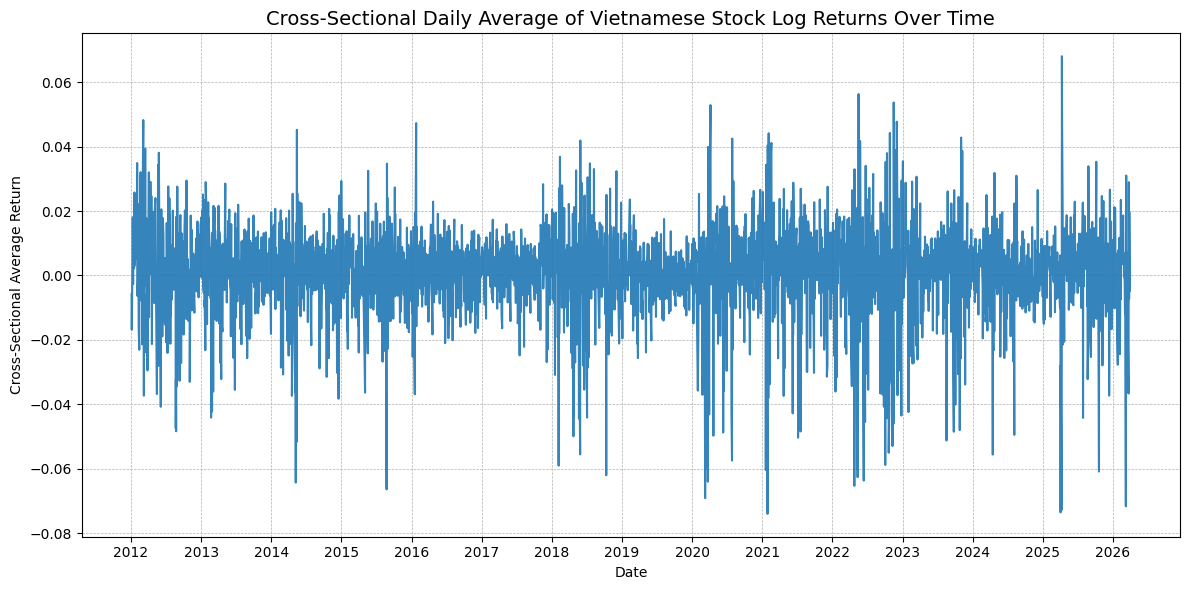

In [23]:
avg_vol = df_vn_ret.mean(axis=1)
# Plot
plt.figure(figsize=(12, 6))
plt.plot(avg_vol, alpha=0.9)
plt.title('Cross-Sectional Daily Average of Vietnamese Stock Log Returns Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cross-Sectional Average Return')
plt.tight_layout()
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
#plt.xticks(rotation=45)
plt.show()

The return volatility is not constant over time and we can observe the phenomenon of Volatility clustering, whereas periods with similar levels of volatility tend to cluster together. This suggests that the Vietnamese financial market undergoes different regimes of volatillty and financial stress.

Analysis of pairwise Pearson correlation.

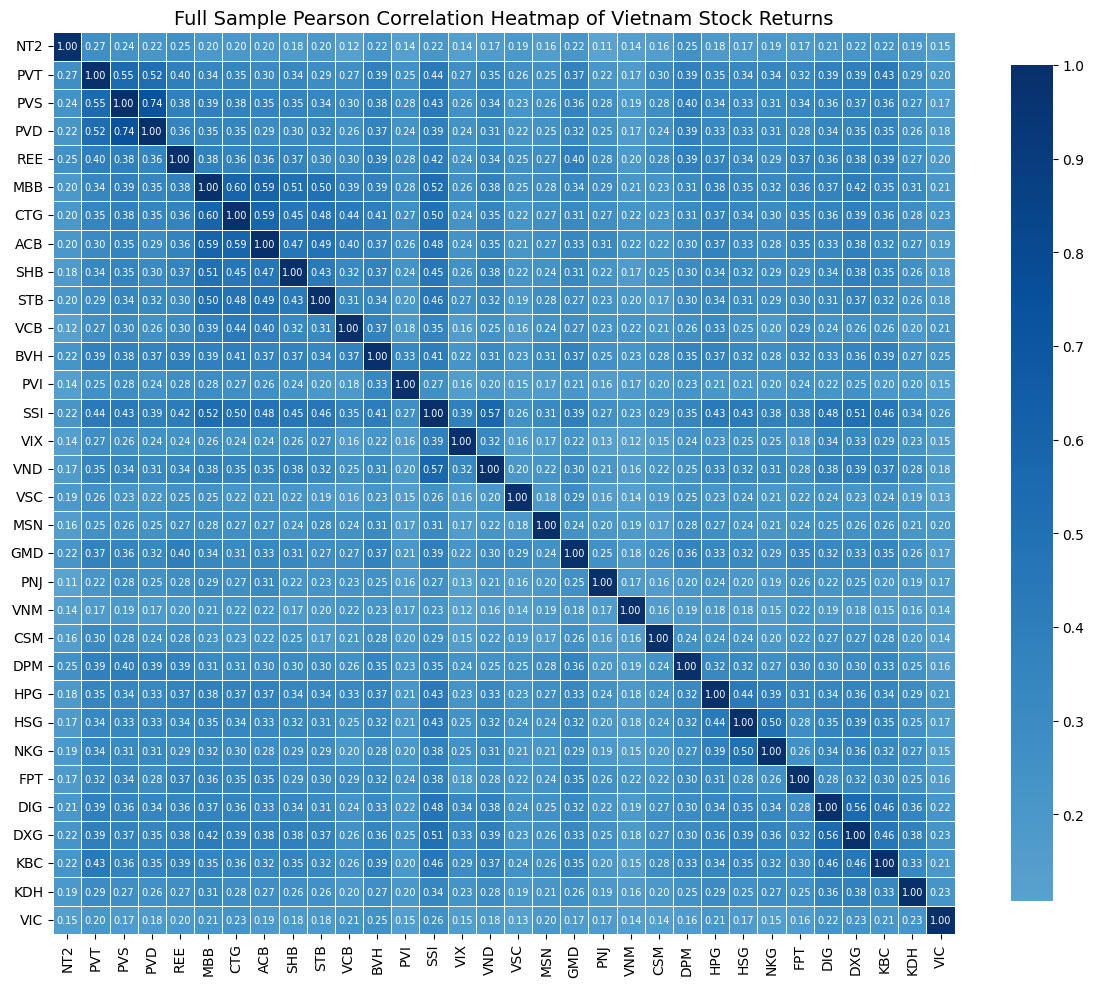

In [24]:
# EDA: Correlation
corr = df_vn_ret.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.9},
    annot_kws={"size": 7}
)

plt.title("Full Sample Pearson Correlation Heatmap of Vietnam Stock Returns", fontsize=14)
#plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The selected assets (representative of systemically important sectors to proxy the Vietnamese market) do not show any negative correlation, which means that the market is directionally unified; in other words, stocks tend to move in the same direction on average, not providing much hedging opportunities, and potentially amplifying shocks via risk of propagation. However, the full-sample correlation is moderate (0.15-0.50 mostly), suggesting that relationships across participants in the Vietnamese market, although being monotonic, may be not be strongly linear (at least, on average).

Not suprisingly, correlations are stronger within the same risk transmission channel:
- Within the Energy & Infrastructure channel, the correlations among companies are higher than the full-sample average, with PV Drilling (PVD) and PetroVietnam Technical Services Corporation (PVS) being the most correlated companies of the full sample (correlation coefficient: 0.74). PVTrans (PVT) has correlation coefficients greater than 0.5 with PVD and PVS (0.52 and 0.55, respectively).
- Within the Financial System channel, MB Bank (MBB) has correlation coefficients higher than 0.5 with VietinBank (CTG), Asia Commercial Bank (ACB), and Saigon-Hanoi Commercial Bank (SHB): 0.6, 0.59, and 0.51, respectively. VietinBank (CTG) and Asia Commercial Bank (ACB) also have a correlation coefficient greater than 0.5, that is 0.59.
- Within the Real Estate channel, Development Investment Construction (DIG) and Dat Xanh Group (DXG) have a correlation coefficient of 0.56.     

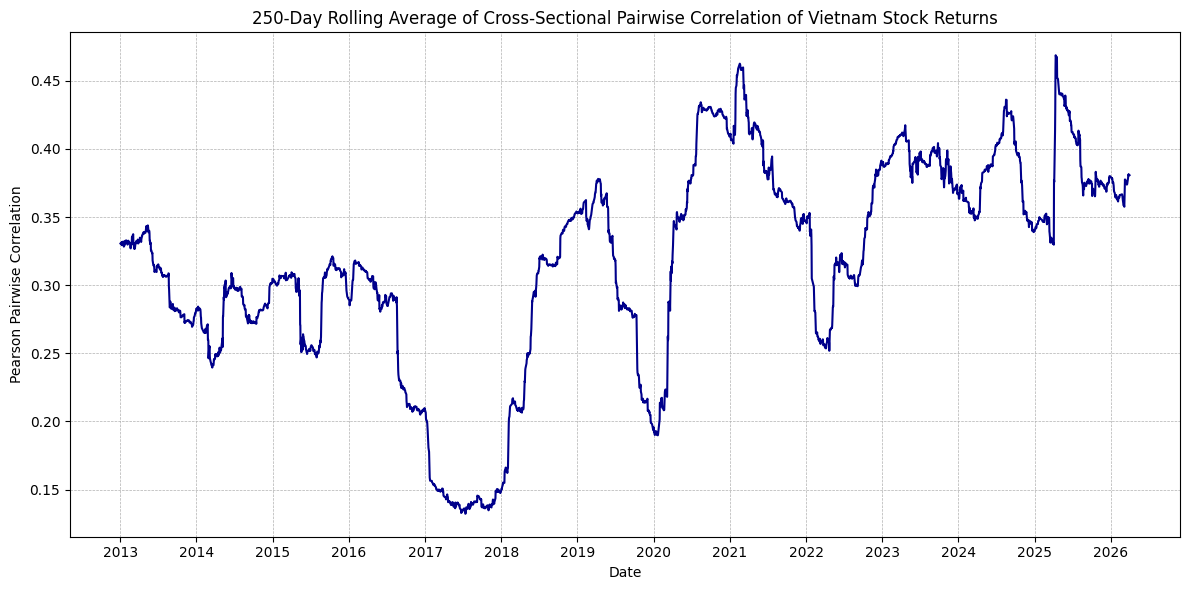

In [25]:
# Rolling (250 days) average pairwise Pearson correlation
# 1. rolling correlation
rolling_corr = df_vn_ret.rolling(250).corr()

# 2. extract average off-diagonal correlation
def avg_off_diag(corr_matrix):
  return corr_matrix.stack().loc[lambda x: x.index.get_level_values(0) != x.index.get_level_values(1)].mean()

# 3. apply for each date
avg_corr = (rolling_corr.groupby(level=0).apply(avg_off_diag))

# Step 4: plot
plt.figure(figsize=(12, 6))
plt.plot(avg_corr, color='darkblue')
plt.title('250-Day Rolling Average of Cross-Sectional Pairwise Correlation of Vietnam Stock Returns')
plt.xlabel('Date')
plt.ylabel('Pearson Pairwise Correlation')
plt.tight_layout()
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.show()

The cross-sectional average pairwise correlation of Vietnam stock returns is time varying, with periods where the market is less synchronized (2016-2017) and years where the market tends to be more unified (2018, 2020, 2023-2025). This suggests periods of time where the Vietnamese market fragility may increase because of a less diversified marketplace, in particual in the most recent years, where the average cross-sectional pairwise correlation tends to be higher than in the previous years.  


The correlation analysis supports the use of systemic risk analytics that can measure the level of market aggregation, or lack of diversification, to quantify the endogenous and time-varying market fragility to shocks and stress events.

Staionarity Test: Augmented Dickey Fuller.

In [26]:
# EDA: Augmented Dickey Fuller Test (ADF) to check for stationarity
for c in df_vn_ret.columns:
  adf_vn = ADF(df_vn_ret[c], trend="n", method="bic")# ADF Test without Drift and Trend
  print("Augmented Dickey Fuller (ADF) Stationarity Test (no drift, no trend) for {} stock returns:\n".format(c), adf_vn)
  print('')

Augmented Dickey Fuller (ADF) Stationarity Test (no drift, no trend) for NT2 stock returns:
    Augmented Dickey-Fuller Results   
Test Statistic                -46.669
P-value                         0.000
Lags                                1
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.

Augmented Dickey Fuller (ADF) Stationarity Test (no drift, no trend) for PVT stock returns:
    Augmented Dickey-Fuller Results   
Test Statistic                -57.604
P-value                         0.000
Lags                                0
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.

Augmented Dickey Fuller (ADF) Stationarity Test (no drift, no trend) for P

All return series are (weakly) stationary, which means that despite time-varying conditional volatilty, the unconditional variance is anyway constant over time.

Analysis of rolling volatility (std), skewness, and (excess) kurtosis.

In [27]:
# EDA: Analysis of rolling volatility (std), skewness, and (excess) kurtosis
window = 250
# Rolling volatility (std)
rolling_vol = df_vn_ret.rolling(window).std()
# Rolling skewness
rolling_skew = df_vn_ret.rolling(window).skew()
# Rolling kurtosis (this is already EXCESS kurtosis in pandas)
rolling_kurt = df_vn_ret.rolling(window).kurt()
#Cross-sectional averages
avg_vol = rolling_vol.mean(axis=1) * np.sqrt(250) #annualized
avg_skew = rolling_skew.mean(axis=1)
avg_kurt = rolling_kurt.mean(axis=1)

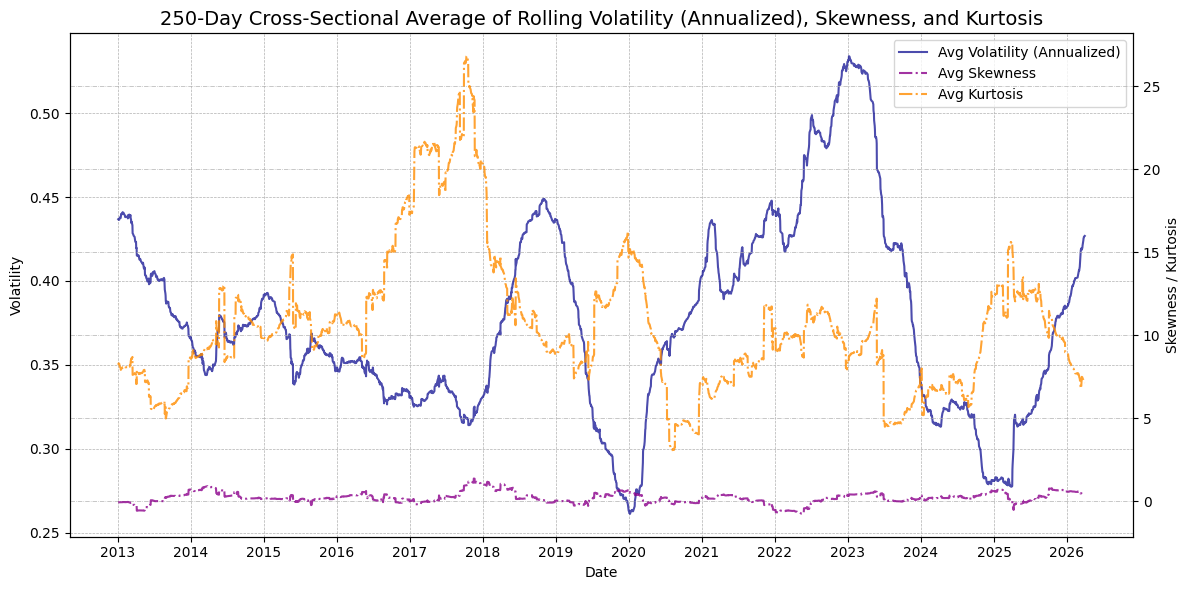

In [28]:
# Plot the cross-sectional average of rolling returns volatility, skewness, and kurtosis over time
fig, ax1 = plt.subplots(figsize=(12, 6))

# Volatility (left axis)
ax1.plot(avg_vol.index, avg_vol, linestyle='-', color='darkblue', label='Avg Volatility (Annualized)', alpha=0.7)
ax1.set_ylabel('Volatility')
ax1.set_title('250-Day Cross-Sectional Average of Rolling Volatility (Annualized), Skewness, and Kurtosis', fontsize=14)
plt.grid(True, linestyle='--', linewidth=.5)
plt.xlabel('Date')

# Second axis for skew/kurt (different scale)
ax2 = ax1.twinx()
ax2.plot(avg_skew.index, avg_skew, linestyle='-.', color='darkmagenta', label='Avg Skewness', alpha=0.8)
ax2.plot(avg_kurt.index, avg_kurt, linestyle='-.', color='darkorange', label='Avg Kurtosis', alpha=0.8)
ax2.set_ylabel('Skewness / Kurtosis')

# Legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.grid(True, linestyle='-.', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

The above chart shows that:
- Cross-sectional annualized average volatility, computed on rolling windows of 250 days (1 year), is significantly time-varying, ranging approximaytely from 25% to 55%. This indicates that, as already observed, the Vietnamese financial market undergoes different regimes of volatillty over time.
- Cross-sectional average kurtosis also exhibits signficant variations over time, staying consistently elevated (compared to a normal distribution) in the whole period, suggesting frequent tail events and significant tail risk.
- Skeweness remains relatively stable and moderate indicating that financial risk doesn't stem from distributional asymmetry but from extreme return movements.

---

**Vietnamese equity trading volume: Exploratory Data Analaysis.**

In [29]:
# EDA: Descriptive Stats for trading volume data
df_vn_vol.describe()/1000

,NT2_volume,PVT_volume,PVS_volume,PVD_volume,REE_volume,MBB_volume,CTG_volume,ACB_volume,SHB_volume,STB_volume,...,DPM_volume,HPG_volume,HSG_volume,NKG_volume,FPT_volume,DIG_volume,DXG_volume,KBC_volume,KDH_volume,VIC_volume
count,3.551000,3.551000,3.5510,3.551000,3.551000,3.551000,3.551000,3.551000,3.551000,3.551000,...,3.551000,3.551000,3.551000,3.551000,3.551000,3.55100,3.551000,3.551000,3.551000,3.551000
mean,555.837316,2066.509335,4364.3251,3645.601605,847.253379,8080.378389,4729.886060,4104.154507,14560.034876,8970.786373,...,1932.257840,12648.834908,5302.043982,3352.543430,2008.258603,5637.32138,6234.095004,3987.274140,1201.652312,1789.690774
std,746.244902,2413.781406,4187.9475,3846.474878,684.189431,10458.778756,5075.358806,5447.007075,22574.224562,10948.826045,...,2494.633578,16879.302141,5860.097416,5098.717385,2926.406205,8868.02613,8063.448716,3948.790594,1906.703045,2559.928180
min,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,106.555000,521.330000,1400.6930,717.540000,379.130000,1184.660000,902.405000,340.037000,2537.679500,916.695000,...,443.775000,1217.615000,599.490000,96.875000,497.290000,455.53000,760.570000,1377.465000,101.500000,400.880000
50%,350.000000,1309.000000,2906.4200,2449.160000,655.700000,4627.510000,3158.400000,2238.672000,6604.443000,4889.230000,...,964.050000,5517.760000,3039.680000,545.980000,1124.500000,1330.19000,2941.680000,2694.420000,303.270000,1013.170000
75%,708.650000,2761.760000,6035.8025,5242.600000,1087.320000,10725.950000,6722.500000,5779.700000,16077.285500,13388.400000,...,2561.150000,19166.900000,8391.560000,5438.600000,2252.315000,7454.15000,8898.600000,5276.045000,1605.050000,2150.400000
max,10592.840000,29040.300000,31261.7490,32482.600000,5689.340000,117471.300000,38922.900000,72249.400000,249681.700000,105089.800000,...,39829.000000,215999.100000,43647.100000,48192.700000,47733.100000,128443.91000,70555.100000,35641.400000,21160.400000,28220.800000


Cross-Sectional Average of Rolling and Daily Trading Volume Over Time.

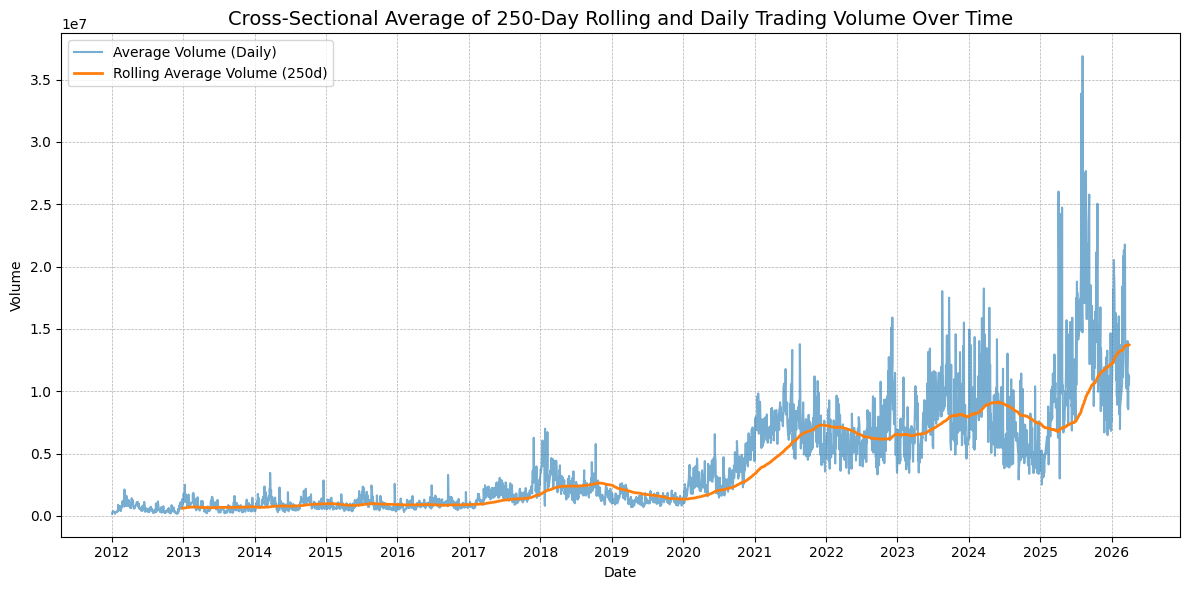

In [30]:
# EDA: Cross-sectional average trading volume over time
avg_volume = df_vn_vol.mean(axis=1)
# Rolling average (250d)
rolling_avg_volume = avg_volume.rolling(250).mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(avg_volume, label='Average Volume (Daily)', alpha=0.6)
plt.plot(rolling_avg_volume, label='Rolling Average Volume (250d)', linewidth=2)

plt.title('Cross-Sectional Average of 250-Day Rolling and Daily Trading Volume Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volume')

plt.legend()
plt.tight_layout()
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.show()

The average trading volume is clearly following an upward trend, specially afer 2020, suggesting an increase in market liquidity and depth. However, volatility of trading volumes has also greatly increased, specially in recent years. These results indicate that market liquidity and depth have indeed increased but liquidity has also become more unstable, suggesting an increased liquidity risk due to periods where liquidity dries up, or suddenly drops after high-liquidity periods.  
The findings support the use of liquidity measures to quantify this dimension of systemic risk, due to unstable and volatilte market liquidity that can drive large market impact, unexpected price slippage, and unpredictable execution risk.

### 2.2. International Data

In [31]:
df_glob

,Date,VNINDEX_close,^AXJO_Close,^FTSE_Close,^GSPC_Close,^GSPTSE_Close,^HSI_Close,^KS11_Close,^N225_Close,^STOXX50E_Close,^TWII_Close,CSI300_close
0,2012-01-02,NaN,NaN,NaN,NaN,NaN,NaN,1826.369995,NaN,NaN,NaN,NaN
1,2012-01-03,350.00,4101.200195,5699.899902,1277.060059,12208.400391,18877.410156,1875.410034,NaN,2389.909912,7053.348145,NaN
2,2012-01-04,348.84,4187.799805,5668.500000,1277.300049,12226.500000,18727.310547,1866.219971,8560.110352,2349.889893,7082.937988,2298.753
3,2012-01-05,340.94,4142.700195,5624.299805,1281.060059,12237.400391,18813.410156,1863.739990,8488.709961,2315.750000,7130.827148,2276.385
4,2012-01-06,336.73,4108.500000,5649.700195,1277.810059,12188.599609,18593.060547,1843.140015,8390.349609,2298.649902,7120.477051,2290.601
...,...,...,...,...,...,...,...,...,...,...,...,...
3701,2026-03-25,1658.19,8557.599609,10106.799805,6591.899902,32382.599609,25335.949219,5642.209961,53749.621094,5649.330078,33439.109375,4537.466
3702,2026-03-26,1644.63,8525.700195,9972.200195,6477.160156,31887.500000,24856.429688,5460.459961,53603.648438,5565.930176,33337.621094,4477.534
3703,2026-03-27,1672.80,8516.299805,9967.400391,6368.850098,31960.699219,24951.880859,5438.870117,53373.070312,5505.799805,33112.589844,4502.570
3704,2026-03-30,1662.54,8461.000000,10128.000000,6343.720215,31934.900391,24750.789062,5277.299805,51885.851562,5541.790039,32518.160156,4491.950


Missing data analysis.

In [32]:
# Check for missing data
for c in df_glob.columns[1:]:
  miss_prc = df_glob[c].isnull().sum()
  print('Missing Price in {} column:'.format(c), miss_prc)

Missing Price in VNINDEX_close column: 158
Missing Price in ^AXJO_Close column: 106
Missing Price in ^FTSE_Close column: 108
Missing Price in ^GSPC_Close column: 125
Missing Price in ^GSPTSE_Close column: 131
Missing Price in ^HSI_Close column: 203
Missing Price in ^KS11_Close column: 211
Missing Price in ^N225_Close column: 223
Missing Price in ^STOXX50E_Close column: 137
Missing Price in ^TWII_Close column: 240
Missing Price in CSI300_close column: 250


We handle missing data by applying forward fill technique to replace NaN values with the last valid observation (no price change on a day the close price is missing).

In [33]:
# Deal with mising values: apply NaN Forward fill by propagating the last valid observation to next valid.
df_glob.ffill(inplace=True)

Transform adjusted close price to logarithmic returns ($r_{t} = ln(\frac{P_{t}}{P_{t-1}})$), clean header names, and set Date column as index.  


In [34]:
df_glob_ret = df_glob.copy()
df_glob_ret = df_glob_ret.dropna()
df_glob_ret = df_glob_ret.set_index('Date')

df_glob_ret = np.log(df_glob_ret / df_glob_ret.shift(1))
df_glob_ret = df_glob_ret.dropna()

df_glob_ret.columns = df_glob_ret.columns.str.replace('_Close', '', regex=False)
df_glob_ret.columns = df_glob_ret.columns.str.replace('_close', '', regex=False)
df_glob_ret.columns = df_glob_ret.columns.str.replace('^', '', regex=False)
df_glob_ret

,VNINDEX,AXJO,FTSE,GSPC,GSPTSE,HSI,KS11,N225,STOXX50E,TWII,CSI300
Date,,,,,,,,,,,
2012-01-05,-0.022907,-0.010828,-0.007828,0.002939,0.000891,0.004587,-0.001330,-0.008376,-0.014635,0.006738,-0.009778
2012-01-06,-0.012425,-0.008290,0.004506,-0.002540,-0.003996,-0.011781,-0.011115,-0.011655,-0.007412,-0.001453,0.006226
2012-01-09,0.007662,-0.000755,-0.006642,0.002259,0.000664,0.014558,-0.009075,0.000000,-0.005322,-0.003865,0.033472
2012-01-10,0.015673,0.011335,0.014927,0.008847,0.006049,0.007318,0.014529,0.003796,0.026338,0.012028,0.032719
2012-01-11,0.007947,0.008466,-0.004557,0.000310,-0.000799,0.007740,-0.004147,0.003037,-0.003397,0.001300,-0.004809
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,0.026534,0.021043,0.014109,0.005404,0.013712,0.010803,0.015772,0.028253,0.012117,0.025038,0.013924
2026-03-26,-0.008211,-0.003735,-0.013407,-0.017559,-0.015407,-0.019108,-0.032743,-0.002719,-0.014873,-0.003040,-0.013296
2026-03-27,0.016983,-0.001103,-0.000481,-0.016863,0.002293,0.003833,-0.003962,-0.004311,-0.010862,-0.006773,0.005576


___

**International data: Exploratory Data Analaysis.**

In [35]:
# EDA: Descriptive Stats for international data
df_glob_ret.describe()

,VNINDEX,AXJO,FTSE,GSPC,GSPTSE,HSI,KS11,N225,STOXX50E,TWII,CSI300
count,3703.000000,3703.000000,3703.000000,3703.000000,3703.000000,3703.000000,3703.000000,3703.000000,3703.000000,3703.000000,3703.000000
mean,0.000424,0.000191,0.000158,0.000441,0.000266,0.000076,0.000269,0.000482,0.000233,0.000405,0.000178
std,0.011443,0.008984,0.009223,0.010392,0.008875,0.012722,0.010875,0.013013,0.011686,0.010072,0.013042
min,-0.069102,-0.102030,-0.115117,-0.127652,-0.131758,-0.141833,-0.128489,-0.132341,-0.132405,-0.102030,-0.091542
25%,-0.004135,-0.003932,-0.004099,-0.003453,-0.003356,-0.006363,-0.004380,-0.005479,-0.004942,-0.003969,-0.005428
50%,0.000723,0.000452,0.000342,0.000348,0.000589,0.000000,0.000053,0.000071,0.000253,0.000210,0.000000
75%,0.006342,0.005001,0.004754,0.005274,0.004459,0.006536,0.005495,0.006997,0.006051,0.005534,0.006038
max,0.065469,0.067665,0.086664,0.090895,0.112945,0.086928,0.091914,0.097366,0.088343,0.088444,0.081420


Analysis of (contemporaneus and lagged) co-movements of global returns with the Vietnamese market (proxied by the VN-Index).

In [36]:
#Contemporaneous Correlation (Full Sample)
vn_corr = df_glob_ret.corrwith(df_glob_ret['VNINDEX']).drop('VNINDEX')
vn_corr.name = 'Contemporaneous Correlation with VN Market (full sample)'
vn_corr

,Contemporaneous Correlation with VN Market (full sample)
AXJO,0.221192
FTSE,0.157555
GSPC,0.092587
GSPTSE,0.119529
HSI,0.217688
KS11,0.247055
N225,0.212206
STOXX50E,0.140716
TWII,0.270616
CSI300,0.167898


In [37]:
# Lagged correlation (Full-sample)
vn_corr_lagged = (df_glob_ret.drop(columns='VNINDEX').shift(1).corrwith(df_glob_ret['VNINDEX']))
vn_corr_lagged.name = 'Lagged (t-1) Correlation with VN Market (full sample)'
vn_corr_lagged

,Lagged (t-1) Correlation with VN Market (full sample)
AXJO,0.083816
FTSE,0.151341
GSPC,0.219270
GSPTSE,0.197935
HSI,0.072483
KS11,0.079291
N225,0.075771
STOXX50E,0.169149
TWII,0.099190
CSI300,0.047649


The Vietnamese market is positively correlated with each index taken into consideration, however the strength of the correlation is moderate: no coefficient is greater than 0.3. This indicates that, although Vietnam tends to move together with the other markets, Vietnam's integration within the global financial network is, historically, still limited.  

It's interesting to note that, whilst contemporanous correlations show a greater integration of Vietnam within the APAC region (Taiwan, South Korea, Australia, Hong Kong, and Japan are the most correlated countries with Vietnam, with coefficients greater than 0.2), the $t-1$ lagged correlation shows that the US, Canada, EU, and UK past returns are the most correlated with Vietnam current one. Thereore, it seems that global financial leaders have historically contributed more than regional ones to causing Vietnam market performance.

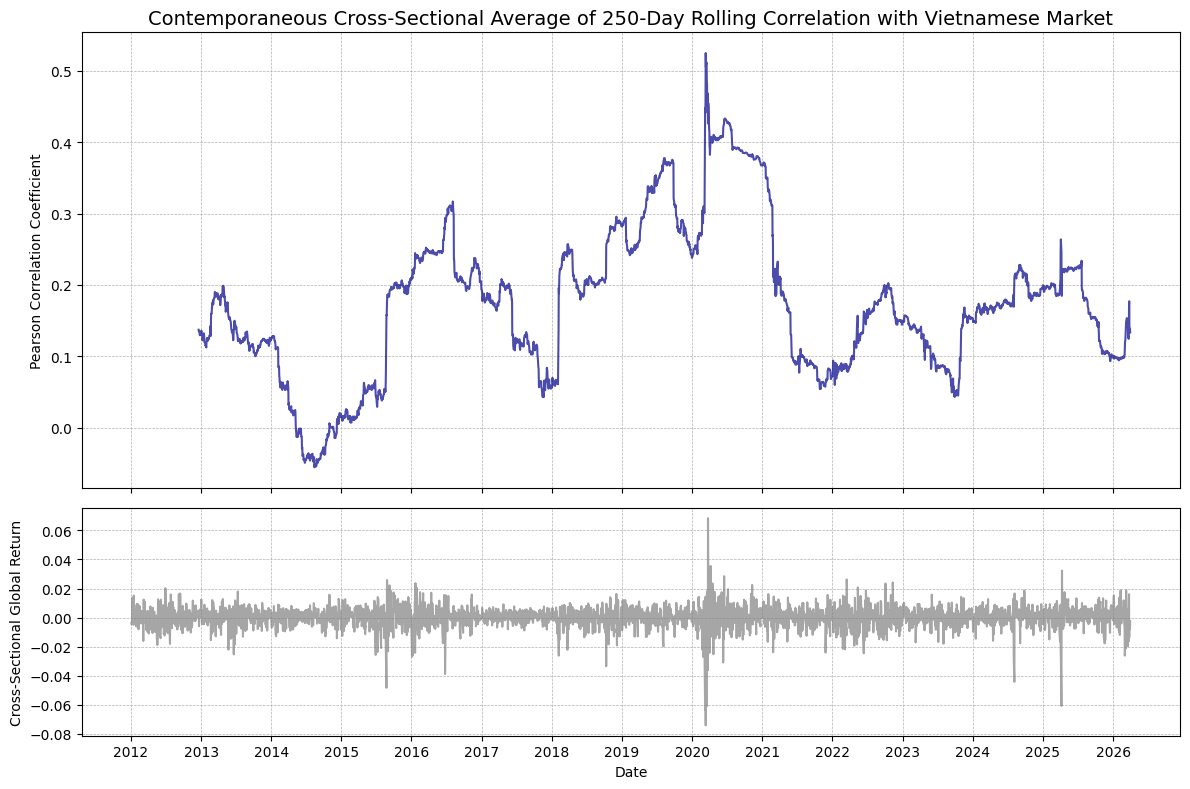

In [38]:
# Contemporaneous Cross-Sectional Average Rolling Correlation with Vietnamese Market
rolling_corr = df_glob_ret.drop(columns='VNINDEX').rolling(250).corr(df_glob_ret['VNINDEX'])
avg_global_ret = df_glob_ret.drop(columns='VNINDEX').mean(axis=1)

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax1.plot(rolling_corr.mean(axis=1), color='darkblue', alpha=0.7)
ax1.set_title('Contemporaneous Cross-Sectional Average of 250-Day Rolling Correlation with Vietnamese Market', fontsize=14)
ax1.set_ylabel('Pearson Correlation Coefficient')
ax1.grid(True, linestyle='--', linewidth=.5)

ax2.plot(avg_global_ret, color='grey', alpha=0.7)
ax2.set_ylabel('Cross-Sectional Global Return')
ax2.set_xlabel('Date')
#ax2.set_title(' Global Returns', fontsize = 11)
ax2.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

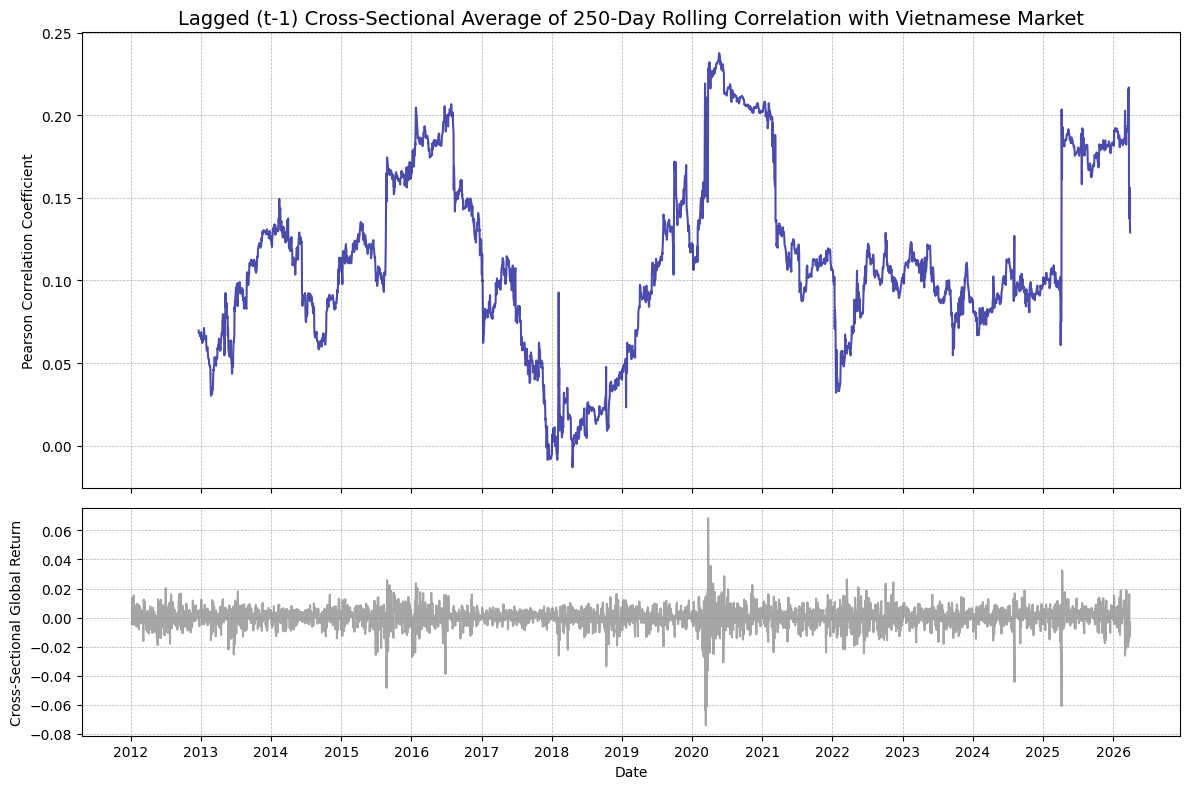

In [39]:
# Lagged (t-1) Cross-Sectional Average Rolling Correlation with Vietnamese Market
rolling_corr_lagged = (df_glob_ret.drop(columns='VNINDEX').shift(1).rolling(250).corr(df_glob_ret['VNINDEX']))
avg_global_ret = df_glob_ret.drop(columns='VNINDEX').shift(1).mean(axis=1)
# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
ax1.plot(rolling_corr_lagged.mean(axis=1), color='darkblue', alpha=0.7)
ax1.set_title('Lagged (t-1) Cross-Sectional Average of 250-Day Rolling Correlation with Vietnamese Market', fontsize=14)
ax1.set_ylabel('Pearson Correlation Coefficient')
ax1.grid(True, linestyle='--', linewidth=.5)

ax2.plot(avg_global_ret, color='grey', alpha=0.7)
ax2.set_ylabel('Cross-Sectional Global Return')
ax2.set_xlabel('Date')
ax2.grid(True, linestyle='--', linewidth=.5)
#ax2.set_title('Cross-Sectional Global Returns', fontsize = 12)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

The lagged ($t-1$) cross-sectional rolling correlation is more moderate than the contemporaneous one, oscillating in a narrower range (contemporaneous: 0 - 0.5; lagged: 0 - 0.25).
This suggests that Vietnam has been historically more sensitive to regional contemporaneous events rather than global past shocks, whose risk of transmissions to the Vietnamese market has been modest and mainly driven by major advanced economies such as the US and Canada.   
It's also interesting to note that spikes in the cross-sectional correlations with Vietnamese market correspond to spikes in the volatility of global returns. This indicates that in time of global financial stress, Vietnam strengthens its integration within the global network right when systemic risk is increasing. The Global Contagion Indicator, based on Granger Causality Nets, will help us understand the time-varying risk spillovers from global markets into Vietnam and the risk contagion dynamics.  


Staionarity Test: Augmented Dickey Fuller.

In [40]:
# EDA: Augmented Dickey Fuller Test (ADF) to check for stationarity
for c in  df_glob_ret.columns:
  adf_glob = ADF(df_glob_ret[c], trend="n", method="bic")# ADF Test without Drift and Trend
  print("Augmented Dickey Fuller (ADF) Stationarity Test (no drift, no trend) for {} Index:\n".format(c), adf_glob)
  print('')

Augmented Dickey Fuller (ADF) Stationarity Test (no drift, no trend) for VNINDEX Index:
    Augmented Dickey-Fuller Results   
Test Statistic                -57.187
P-value                         0.000
Lags                                0
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.

Augmented Dickey Fuller (ADF) Stationarity Test (no drift, no trend) for AXJO Index:
    Augmented Dickey-Fuller Results   
Test Statistic                -67.503
P-value                         0.000
Lags                                0
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.

Augmented Dickey Fuller (ADF) Stationarity Test (no drift, no trend) for FTSE Index:


All series for the index returns are (weakly) stationary and therefore suited for Granger Causality analysis.

## 3. Devising Risk Indicators to Quantify Different Systemic Risk Dimensions.

In [41]:
#Import the needed libraries
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")
import networkx as nx
#try:
#  from pca import pca
#except:
#  !pip install pca
#  from pca import pca
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

### 3.1. Vietnam Global Contagion Indicator (VGCI)

Import datafame from Granger Causality tests performed in the notebook <a href='https://github.com/SebastianoDenegri/a_systemic_risk_framework_for_the_vietnamese_market/blob/main/Estimating_the_pairwise_Granger_coefficents_for_the_VGCI.ipynb'>Estimating the pairwise Granger coefficents across International Markets for the Vietnam Global Contagion Indicator (VGCI)</a>, hosted on this same repository: <a href='https://github.com/SebastianoDenegri/a_systemic_risk_framework_for_the_vietnamese_market.git'>a_systemic_risk_framework_for_the_vietnamese_market
</a>.

In [42]:
gc_rolling_df = import_data(file_path)

Drive not available or file missing: Error: credential propagation was unsuccessful
Please upload dataframe manually.


Saving gc_rolling_df.parquet to gc_rolling_df.parquet
Loaded gc_rolling_df.parquet from manual upload.


In [43]:
#show a slice of data from gc_rolling_df
gc_rolling_df[(gc_rolling_df["date"] == "2012-12-21") & (gc_rolling_df["caused"] == "VNINDEX")]

,date,causing,caused,lag,coef,p_value
110,2012-12-21,AXJO,VNINDEX,1,0.092783,0.408517
111,2012-12-21,FTSE,VNINDEX,1,0.169176,0.065328
112,2012-12-21,GSPC,VNINDEX,1,0.175769,0.086413
113,2012-12-21,GSPTSE,VNINDEX,1,0.074172,0.494887
114,2012-12-21,HSI,VNINDEX,1,0.052449,0.498941
115,2012-12-21,KS11,VNINDEX,1,0.073144,0.390621
116,2012-12-21,N225,VNINDEX,1,0.034988,0.663051
117,2012-12-21,STOXX50E,VNINDEX,1,0.118026,0.057322
118,2012-12-21,TWII,VNINDEX,1,0.075081,0.371294
119,2012-12-21,CSI300,VNINDEX,1,-0.032986,0.612228


In [44]:
# Compute the "Number of “In” Connections" for Vietnam, that is the number of countries, per date, that significantly (confidence = 5%) Granger-cause Vietnam
pvalue_threshold = 0.05
# Keep only rows where VNINDEX is the affected market
vn_inbound = gc_rolling_df[gc_rolling_df["caused"] == "VNINDEX"]
# Create a TRUE/FALSE column for significance
vn_inbound["is_significant"] = vn_inbound["p_value"] < pvalue_threshold
# Keep only significant rows
sig_coef = vn_inbound[vn_inbound["is_significant"]]
# Count unique "causing" per date
in_degree = sig_coef.groupby("date")["causing"].nunique()
# Step 6: add back missing dates with 0
in_degree = in_degree.reindex(vn_inbound["date"].unique(), fill_value=0)
# Step 7: make it a clean dataframe
in_degree = in_degree.rename("in_connections").to_frame()

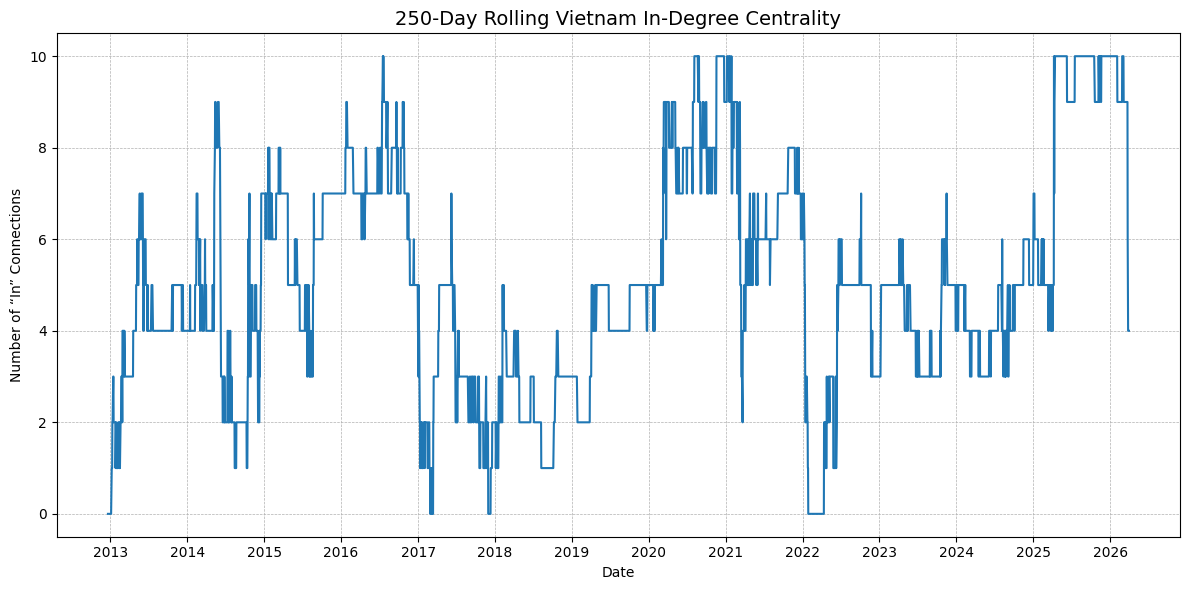

In [45]:
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.plot(in_degree)
plt.title('250-Day Rolling Vietnam In-Degree Centrality', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of “In” Connections')
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [46]:
# compute the "Inbound Closeness:" for Vietnam, that is the shortest path from every other country to reach to Vietnam
results = []
target = "VNINDEX"

for date, df_day in gc_rolling_df.groupby("date"):
  df_sig = df_day[df_day["p_value"] < pvalue_threshold]
  G = nx.DiGraph()
  for _, row in df_sig.iterrows():
    G.add_edge(row["causing"], row["caused"])
  G.add_node(target)

  nodes = set(G.nodes())
  sources = nodes - {target}
  N = len(nodes)
  score = 0
  for i in sources:
    try:
      d = nx.shortest_path_length(G, source=i, target=target)
      score += 1 / d
    except nx.NetworkXNoPath:
      score += 0

  score = score / (N - 1) if (N - 1) > 0 else 0
  results.append([date, score])

inbound_closeness = pd.DataFrame(results, columns=["date", "inbound_closeness"]).set_index('date')

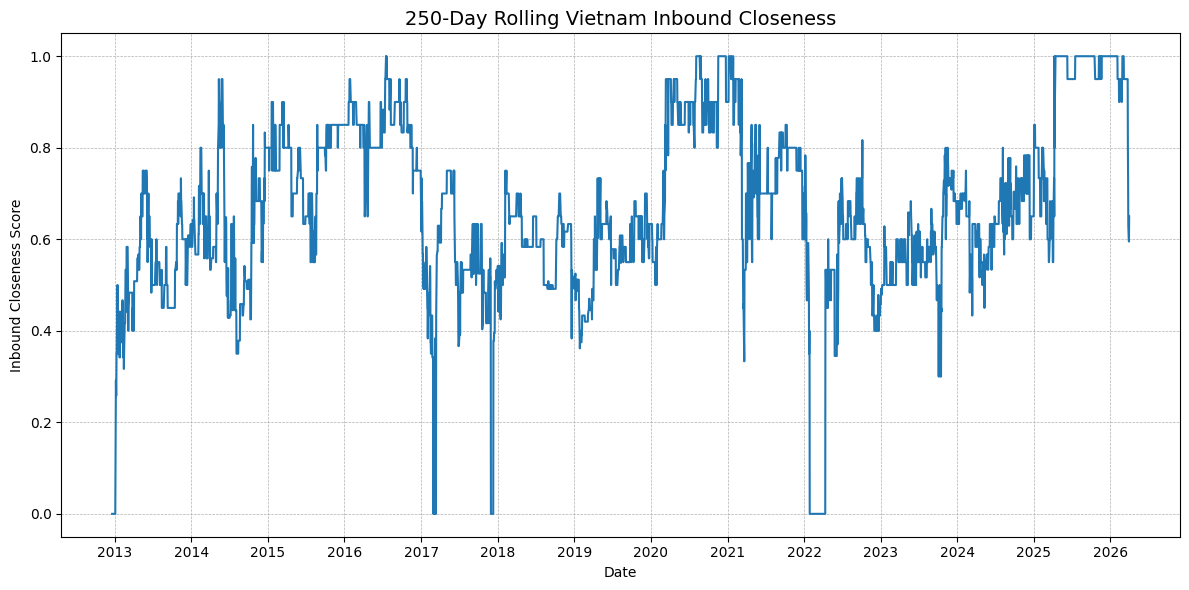

In [47]:
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.plot(inbound_closeness)
plt.title('250-Day Rolling Vietnam Inbound Closeness', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Inbound Closeness Score')
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

In [48]:
# Build a directed weighted adjacency matrix A, where A_{ij}>0 if i Granger-causes j; 0 otherwise.
## Edge values in A are estimated as the corresponding, statistically significant, and positive Granger causality coefficients.
adjacency_matrices = {}
mean_coef = 0
num_adj_mtx = 0
for date, df_day in gc_rolling_df.groupby("date"):
  # keep only significant + positive Granger links
  df_sig = df_day[(df_day["p_value"] < pvalue_threshold) & (df_day["coef"] > 0)]
  # get full set of nodes for this day
  nodes = pd.unique(pd.concat([df_day["causing"], df_day["caused"]]))
  # initialize adjacency matrix
  A = pd.DataFrame(0.0, index=nodes, columns=nodes)
  # fill adjacency matrix
  for _, row in df_sig.iterrows():
    i = row["causing"]
    j = row["caused"]
    A.loc[i, j] = row["coef"]
  num_adj_mtx += 1  # Keep count of the number of adjacency matrix
  mean_coef += A.mean().mean()
  adjacency_matrices[date] = A
base_centrality = mean_coef/num_adj_mtx #Calculate the mean coefficient across all matrices

In [49]:
eigen_vn = []
invalid=0
for date, A in adjacency_matrices.items():
  # Give each node a base centrality value calculated as the macro-average of coefficients across all adjacency matrices to avoid sparsity and enhance numerical stability:
  A = A + base_centrality
  # Calculate eigenvectors and eigenvalues:
  eigenvalues, eigenvectors = np.linalg.eig(A.T)
  idx = eigenvalues.real.argmax() #do not consider complex part of eigenvalues
  vec = eigenvectors[:, idx].real #do not consider complex part of eigenvectors
  if (np.any(vec > 0) and np.any(vec < 0)): #Check if eigenvectors have both positive and negative elements
    invalid +=1
  elif vec.sum() < 0:
    vec = -vec #flip the sign of all elements in case of negative eigenvectors to enhance numerical stability
  eigen_vn.append({'date': date,'vn_loading': vec[A.index.get_loc("VNINDEX")]})

eigen_vn = pd.DataFrame(eigen_vn).set_index('date')

In [50]:
print('Number of Eigenvectors with mixed-sign elements:', invalid)

Number of Eigenvectors with mixed-sign elements: 0


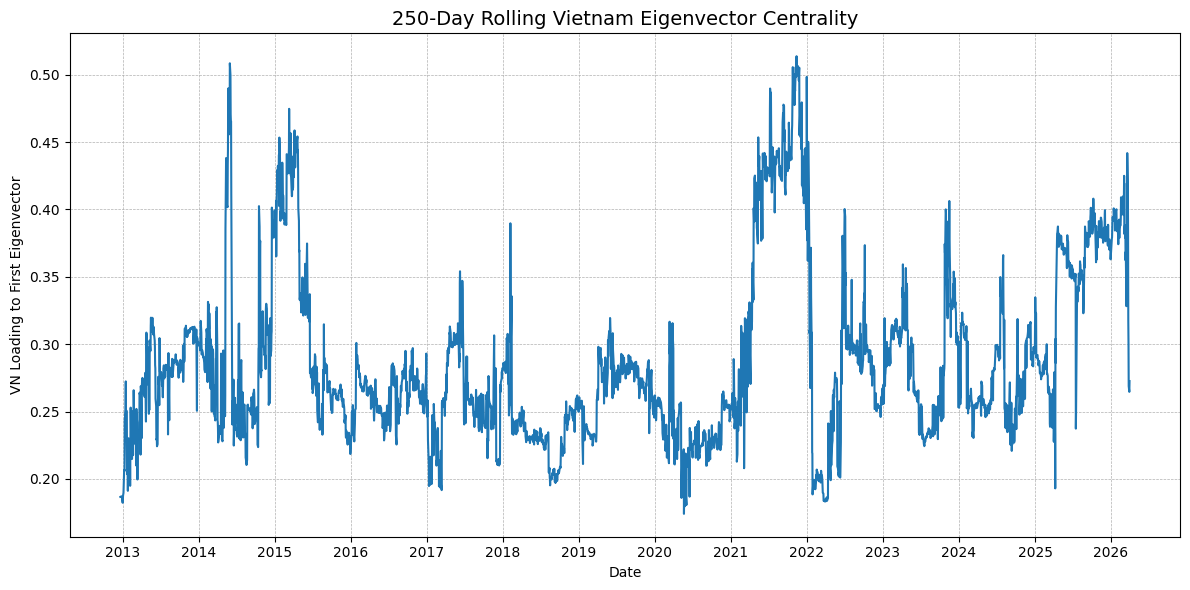

In [51]:
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.plot(eigen_vn)
plt.title('250-Day Rolling Vietnam Eigenvector Centrality', fontsize=14)
plt.xlabel('Date')
plt.ylabel('VN Loading to First Eigenvector')
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

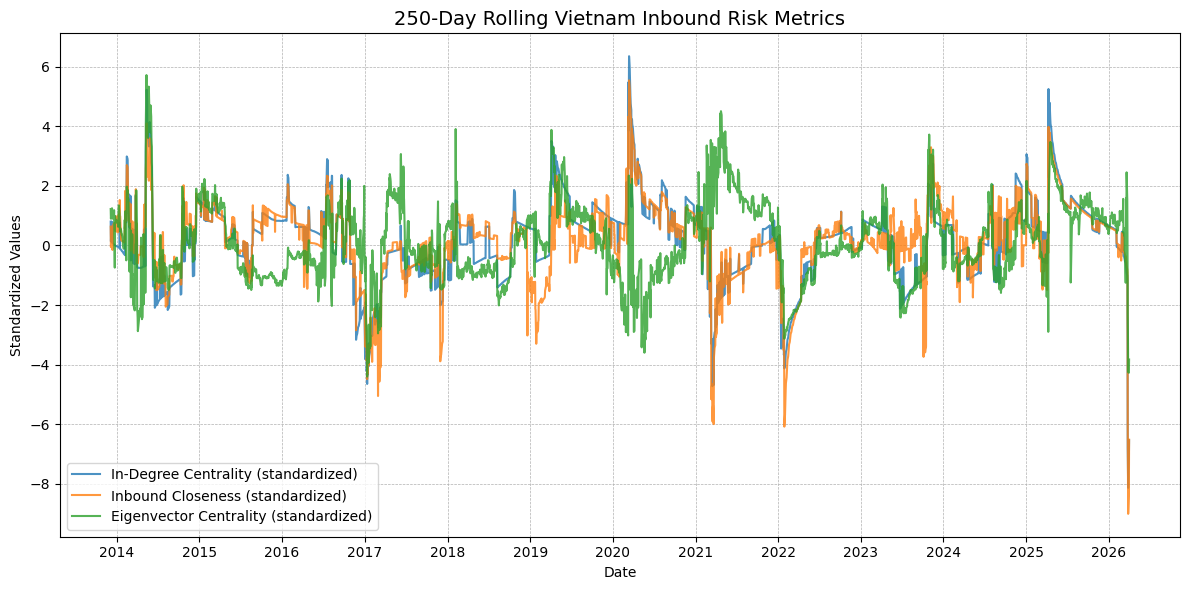

In [52]:
vn_inbound_metrics =  pd.concat([in_degree, inbound_closeness, eigen_vn], axis=1)
vn_inbound_metrics_std = (vn_inbound_metrics- vn_inbound_metrics.rolling(250).mean()) / vn_inbound_metrics.rolling(250).std()
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.plot(vn_inbound_metrics_std['in_connections'], label='In-Degree Centrality (standardized)', alpha=0.8)
plt.plot(vn_inbound_metrics_std['inbound_closeness'], label='Inbound Closeness (standardized)', alpha=0.8)
plt.plot(vn_inbound_metrics_std['vn_loading'], label='Eigenvector Centrality (standardized)', alpha=0.8)
plt.title('250-Day Rolling Vietnam Inbound Risk Metrics', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Standardized Values')
plt.grid(True, linestyle='--', linewidth=.5)
plt.legend()
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

---

In [53]:
#Estimate regression of coefficients of the 3 inbound centrality metrics (in-degree, inbound closeness, eigenvector centrality) against the 250-day rolling maximum drawdown of the VN-Index returns.
##Calculate Max Drawdown for Regression
#window = 250
#logret = df_glob_ret["VNINDEX"]
## rolling cumulative return path
#cumret = np.exp(logret.cumsum())
## rolling peak
#rolling_peak = cumret.rolling(window).max()
## drawdow:
#drawdown = (cumret - rolling_peak)/rolling_peak
## Max Drawdown in Window (make positive = the higher the worst)
#vn_stress = -drawdown.rolling(window).min()

In [54]:
#fig, ax1 = plt.subplots(figsize=(12, 6))
#plt.plot(vn_stress)
#plt.title('Vietnam Financial Stress (Sign-Flipped VN-Index Maximum Drawdown)', fontsize=14)
#plt.xlabel('Date')
#plt.ylabel('Sign-Flipped VN-Index Maximum Drawdown')
#plt.grid(True, linestyle='--', linewidth=.5)
#ax = plt.gca()
#ax.xaxis.set_major_locator(mdates.YearLocator(1))
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
#plt.tight_layout()
#plt.show()

In [55]:
#vgci_regr = []
#alpha = 25  # tune this (0.1, 1, 10)
#window=250
#data = pd.concat([vn_inbound_metrics_std, vn_stress], join='inner', axis=1).dropna()
#for t in range(window, len(data)):
#  X_window = data.iloc[t-window:t][['in_connections','inbound_closeness','vn_loading']].values
#  y_window = data.iloc[t-window:t]['VNINDEX'].values
#  model = Ridge(alpha=alpha, fit_intercept=True)
#  model.fit(X_window, y_window)
#  x_t = data.iloc[t][['in_connections','inbound_closeness','vn_loading']].values.reshape(1, -1)
#  vgci_t = model.predict(x_t)[0]
#  vgci_regr.append(vgci_t)

#vgci_regr = pd.Series(vgci_regr, index=data.index[window:])

In [56]:
#fig, ax1 = plt.subplots(figsize=(12, 6))
#plt.plot(vgci_regr)
#plt.plot(vn_stress)
#plt.title('250-Day Rolling Vietnam Global Centrality Indicator (Regressed)', fontsize=14)
#plt.xlabel('Date')
#plt.ylabel('VGCI')
#plt.grid(True, linestyle='--', linewidth=.5)
#ax = plt.gca()
#ax.xaxis.set_major_locator(mdates.YearLocator(1))
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
#plt.tight_layout()
#plt.show()

---

In [57]:
window = 250
c_wind = 0
pc1_expl_var = 0
vn_inbound_metrics_std = vn_inbound_metrics_std.dropna()
vgci = pd.Series(index=vn_inbound_metrics_std.index, dtype=float)
for i in range(window, len(vn_inbound_metrics_std)):
  X = vn_inbound_metrics_std.iloc[i-window:i]
  pca = PCA(n_components=1).fit(X)
  w = pca.components_[0]
  vgci.iloc[i] = (vn_inbound_metrics_std.iloc[i] * w).sum()
  pc1_expl_var += pca.explained_variance_ratio_
  c_wind += 1

avg_expl_var = pc1_expl_var/c_wind
vgci = vgci.rename('VGCI')

In [58]:
print('Average Variance Explained by First Principal Component Across Windows: {}%'.format(round(avg_expl_var[0]*100,2)))

Average Variance Explained by First Principal Component Across Windows: 79.26%


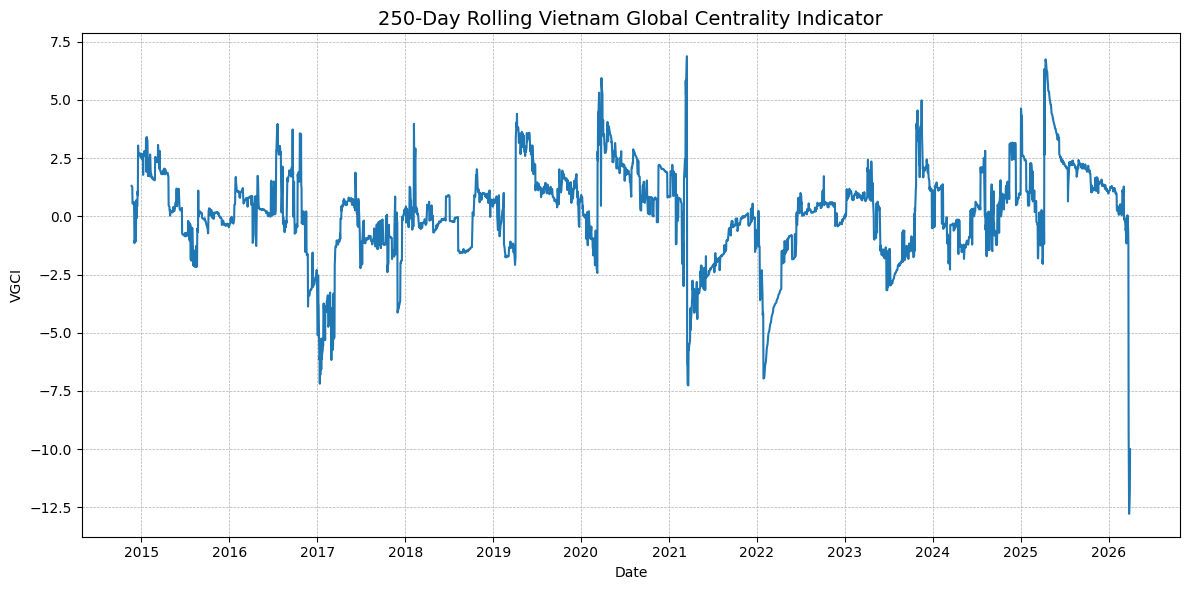

In [59]:
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.plot(vgci)
plt.title('250-Day Rolling Vietnam Global Centrality Indicator', fontsize=14)
plt.xlabel('Date')
plt.ylabel('VGCI')
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

### 3.2. Vietnam Market Fragility Indicator (VMFI).

In [60]:
k = int(0.2 * df_vn_ret.shape[1]) #Number of components: 1/5th of the number of analyzed assets
window = 250
ar = pd.Series(index=df_vn_ret.index, dtype=float)
for i in range(window, len(df_vn_ret)):
  X = df_vn_ret.iloc[i-window:i]
  pca = PCA(n_components=k).fit(X)
  ar.iloc[i] = pca.explained_variance_ratio_.sum()

ar = ar.rename('absorption_ratio')

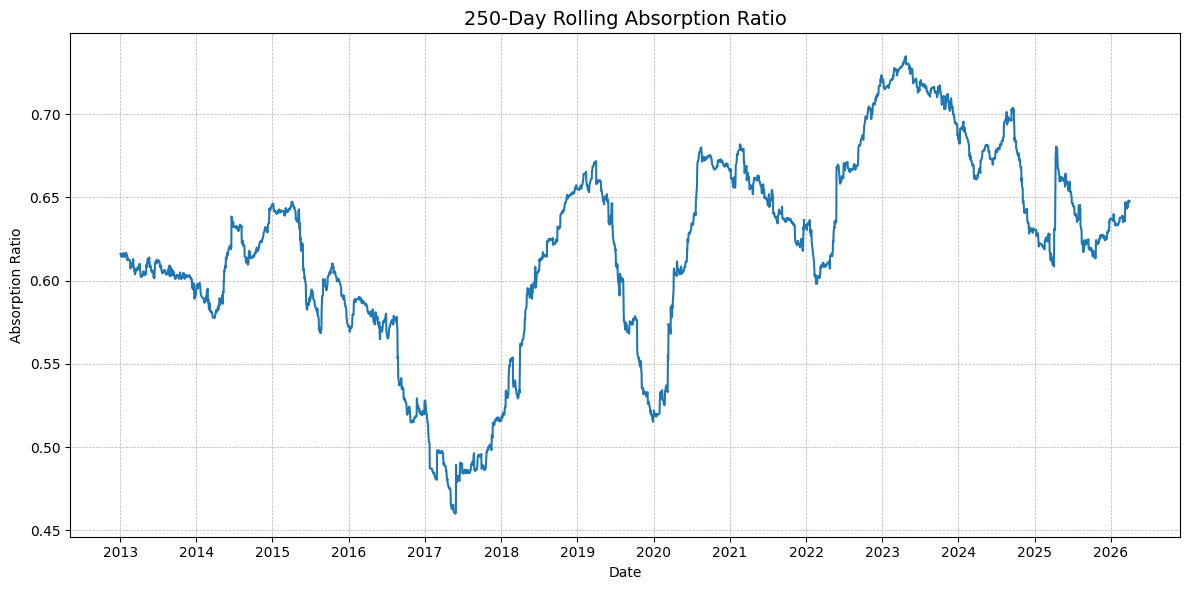

In [61]:
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.plot(ar, linestyle='-')#, label='Absorption Ratio', alpha=0.9)
plt.title('250-Day Rolling Absorption Ratio', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Absorption Ratio')
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
#plt.legend()
plt.tight_layout()
plt.show()

In [62]:
ar_shift = ((ar.rolling(15).mean() - ar.rolling(250).mean()) / ar.rolling(250).std()).rename("AR_standardized_shift")

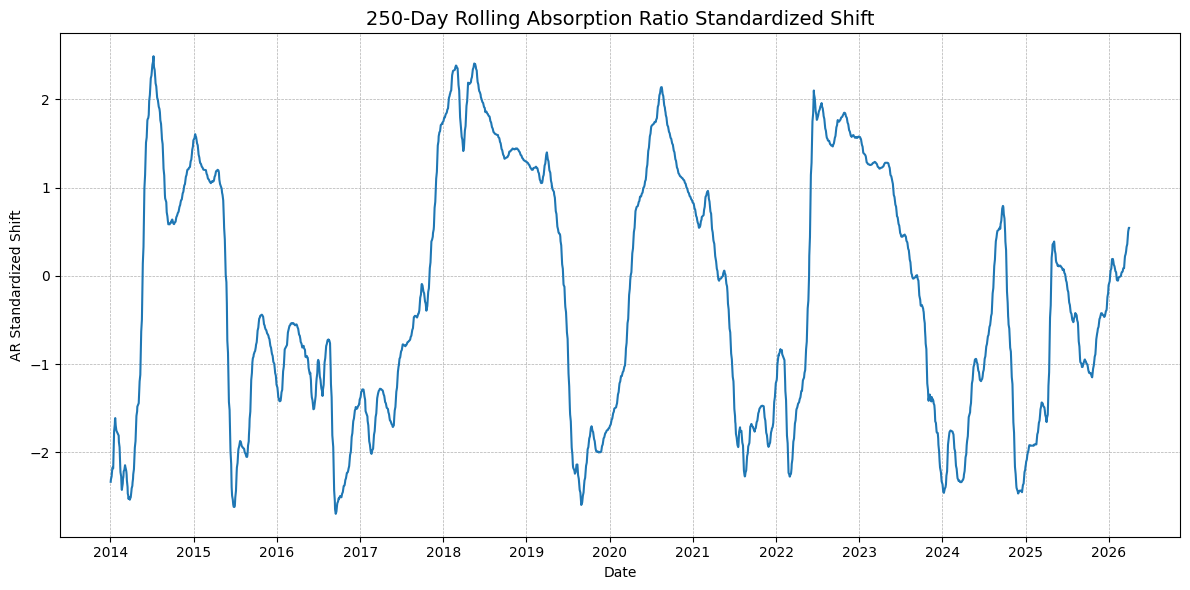

In [63]:
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.plot(ar_shift)#, linestyle='-')#, label='Absorption Ratio', alpha=0.9)
plt.title('250-Day Rolling Absorption Ratio Standardized Shift', fontsize=14)
plt.xlabel('Date')
plt.ylabel('AR Standardized Shift')
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
#plt.legend()
plt.tight_layout()
plt.show()

In [64]:
#Standardize the Absorption Ratio and AR Standardized Shift on 250-day rolling windows
ar_std = (ar - ar.rolling(window).mean()) / ar.rolling(window).std()
ar_shift_std = (ar_shift - ar_shift.rolling(window).mean()) / ar_shift.rolling(window).std()

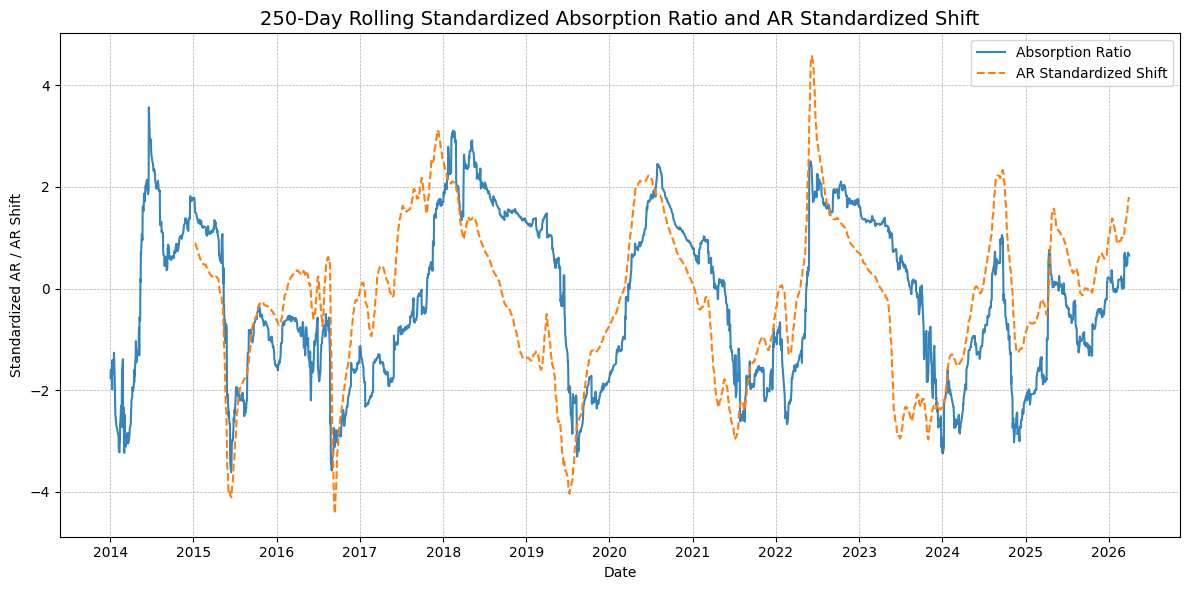

In [65]:
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.plot(ar_std, linestyle='-', label='Absorption Ratio', alpha=0.9)
plt.plot(ar_shift_std, linestyle='--', label='AR Standardized Shift', alpha=1)
plt.title('250-Day Rolling Standardized Absorption Ratio and AR Standardized Shift', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Standardized AR / AR Shift')
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.legend()
plt.tight_layout()
plt.show()

In [66]:
#Compute the Vietnam Market Fragility Indicator
vmfi = (.5*ar_std + .5*ar_shift_std).rename('VMFI')

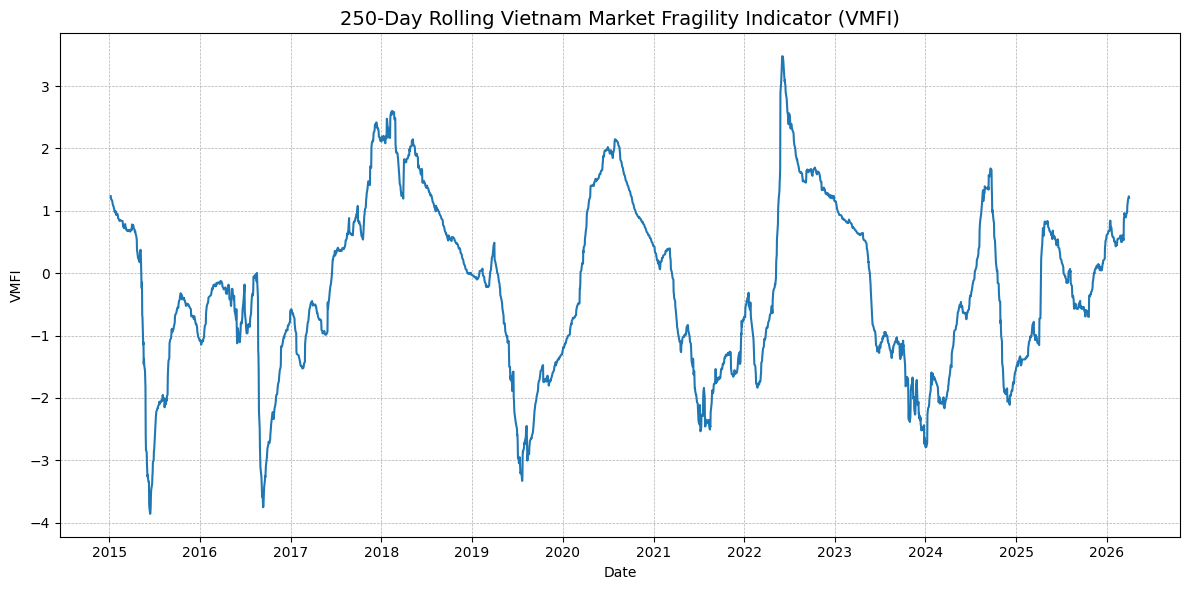

In [67]:
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.plot(vmfi)
plt.title('250-Day Rolling Vietnam Market Fragility Indicator (VMFI)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('VMFI')
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

### 3.3. Vietnam Financial Turbulence Indicator (VFTI).

In [68]:
# Compute the Squared Mahalanobis Distance as the Vietnam Financial Turbulence Indicator (VFTI)
window = 250
md2 = []

for i in range(window, len(df_vn_ret)):
  w = df_vn_ret.iloc[i-window:i]
  d = df_vn_ret.iloc[i] - w.mean()
  md2.append(d.T @ np.linalg.inv(w.cov()) @ d)

vfti = pd.Series(md2, index=df_vn_ret.index[window:]).rename('VFTI')

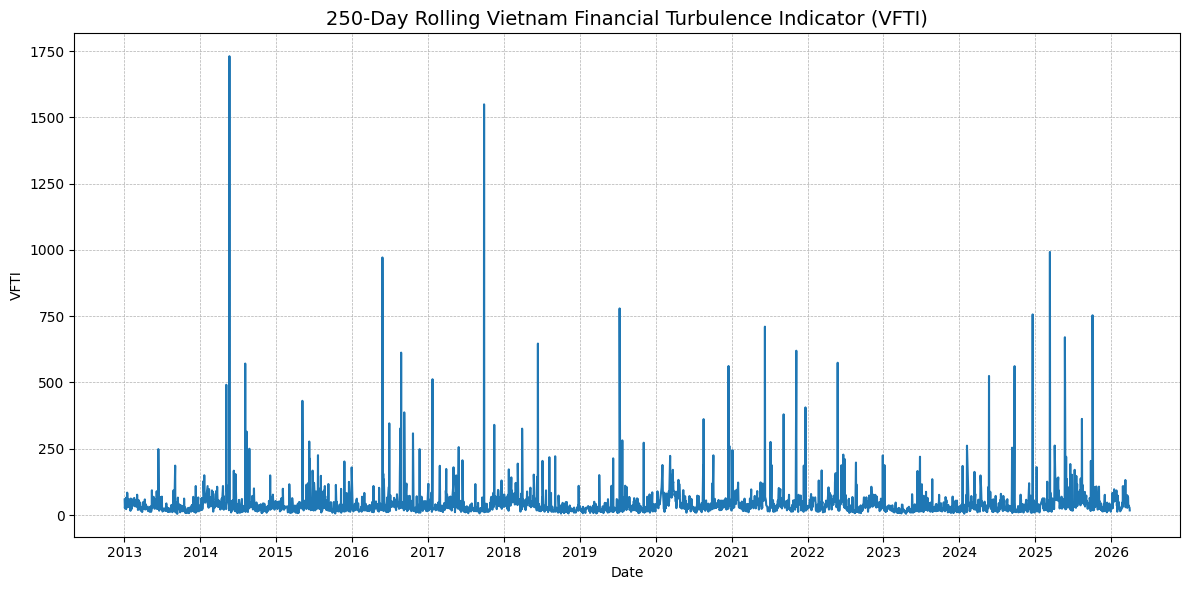

In [69]:
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.plot(vfti)
plt.title('250-Day Rolling Vietnam Financial Turbulence Indicator (VFTI)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('VFTI')
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

### 3.4. Vietnam Tail Risk Indicator (VTRI).

Import datafame with $\Delta$CoVaR values estimated in the notebook <a href=''>Estimating the pairwise Granger coefficents across International Markets for the Vietnam Global Contagion Indicator (VGCI)</a>, hosted on this same repository: <a href='https://github.com/SebastianoDenegri/a_systemic_risk_framework_for_the_vietnamese_market.git'>a_systemic_risk_framework_for_the_vietnamese_market
</a>.

In [70]:
delta_covar = import_data(file_path)

Drive not available or file missing: Error: credential propagation was unsuccessful
Please upload dataframe manually.


Saving delta_covar.parquet to delta_covar.parquet
Loaded delta_covar.parquet from manual upload.


In [71]:
#Calculate rolling aggrgate DeltaCoVaR
window = 250
df_vn_price.columns = df_vn_price.columns.str.replace('_close', '', regex=False)
df_vn_vol.columns = df_vn_vol.columns.str.replace('_volume', '', regex=False)

#Calcualte Weights:
# Calculate the daily trading volume in monetary terms
monetary_vol = df_vn_price * df_vn_vol
# Rolling average (per stock)
avg_traded_value = monetary_vol.rolling(window).mean()
# Compute the weights to sum up to 1
weights = avg_traded_value.div(avg_traded_value.sum(axis=1), axis=0)
weights = weights.loc[delta_covar.index]
vtri = (weights * delta_covar).sum(axis=1).rename('VTRI')
vtri = -vtri

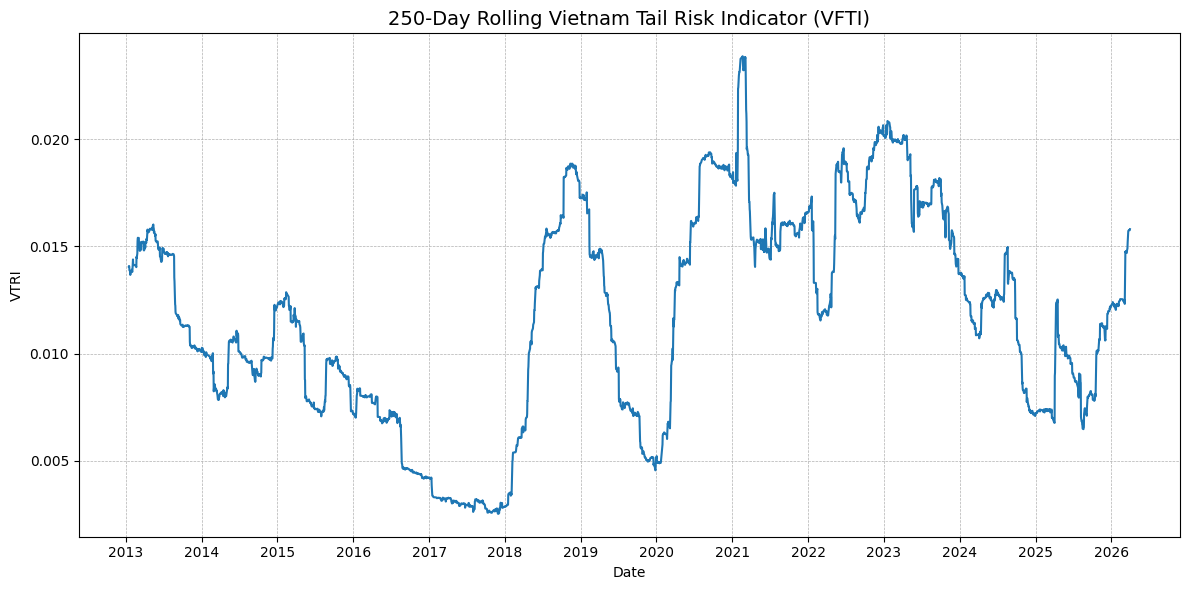

In [72]:
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.plot(vtri.loc['2013-01-15':])
plt.title('250-Day Rolling Vietnam Tail Risk Indicator (VFTI)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('VTRI')
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

### 3.5. Vietnam Market Illiquidity Indicator (VMII).

In [73]:
# Compute the Amihud Illiquity measure per each stock on 250-day roling windows
# Calculate daily ILLIQ measure per stock
illiq_daily = df_vn_ret.abs() / monetary_vol.replace(0, np.nan)
# Calculate ILLIQ measure per stock over 250-day rolling windows
amihud_250d = illiq_daily.rolling(250, min_periods=250).mean()
# Calculate Vietnam Market Illiquidity Indicator (VMII) as the cross-sectional simple average of the single-stock Amihud Illiquidity measures
vmii = (amihud_250d.mean(axis=1)).rename('VMII')

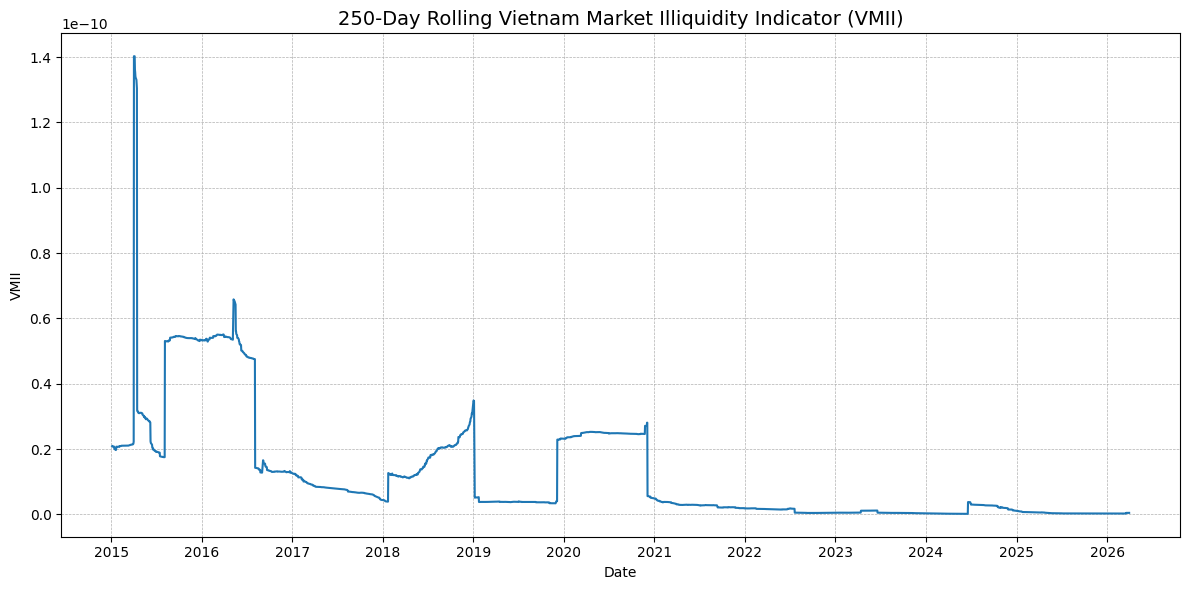

In [74]:
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.plot(vmii.loc['2015-01-01':])
plt.title('250-Day Rolling Vietnam Market Illiquidity Indicator (VMII)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('VMII')
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

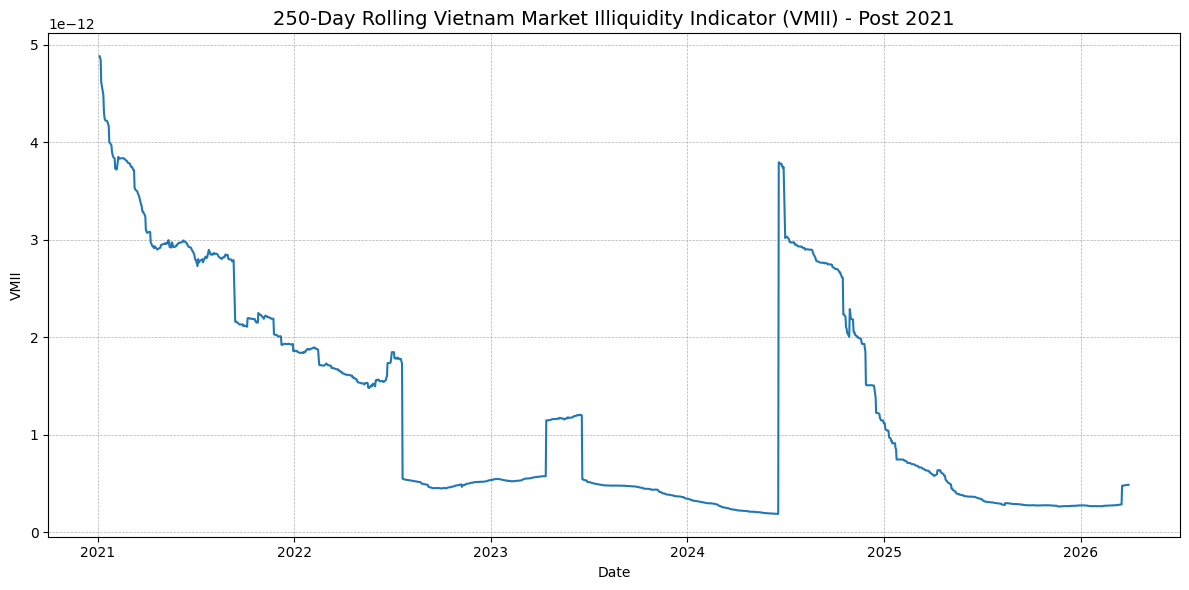

In [75]:
fig, ax1 = plt.subplots(figsize=(12, 6))
plt.plot(vmii.loc['2021-01-01':])
plt.title('250-Day Rolling Vietnam Market Illiquidity Indicator (VMII) - Post 2021', fontsize=14)
plt.xlabel('Date')
plt.ylabel('VMII')
plt.grid(True, linestyle='--', linewidth=.5)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 4. Build the Composite Vietnam Systemic Risk Index (VSRI).

### 4.1. Consolidating the Risk Indicators into one Dataframe.

In [76]:
risk_indicators = pd.concat([vgci, vmfi, vfti, vtri, vmii],axis=1).dropna()
risk_indicators.columns = ['VGCI', 'VMFI', 'VFTI', 'VTRI', 'VMII']
risk_indicators

,VGCI,VMFI,VFTI,VTRI,VMII
2015-01-07,2.673896,1.236732,25.683650,0.012310,2.076431e-11
2015-01-08,1.779384,1.202193,22.429705,0.012376,2.080910e-11
2015-01-09,2.512189,1.183160,47.436271,0.012385,2.082691e-11
2015-01-12,2.745392,1.171150,34.434973,0.012331,2.080509e-11
2015-01-13,2.799012,1.161925,50.356382,0.012294,2.066579e-11
...,...,...,...,...,...
2026-03-25,-9.236714,1.121671,31.721535,0.015741,4.838251e-13
2026-03-26,-10.829427,1.176678,35.852289,0.015747,4.846243e-13
2026-03-27,-12.777601,1.182651,31.610264,0.015761,4.852439e-13
2026-03-30,-11.795867,1.232783,27.907488,0.015750,4.864489e-13


### 4.2. Transforming the Risk Indicators based on their Empirical Cumulative Distribution Function (ECDF) via Order Statistics.

In [77]:
cols = ['VGCI', 'VMFI', 'VFTI', 'VTRI', 'VMII']
window = 250
# initialize output
risk_ecdf = pd.DataFrame(index=risk_indicators.index, columns=cols, dtype=float)
for col in cols:
  series = risk_indicators[col]
  for t in range(window, len(series)):
    w = series.iloc[t - window : t]
    # rank within window (order statistics)
    ranks = w.rank(method='average')
    # ECDF evaluated at the LAST observation in the window
    ecdf = ranks.iloc[-1] / (window + 1)
    # store at time t
    risk_ecdf.iloc[t, risk_ecdf.columns.get_loc(col)] = ecdf

risk_ecdf = risk_ecdf.dropna()
risk_ecdf

,VGCI,VMFI,VFTI,VTRI,VMII
2016-01-08,0.386454,0.298805,0.557769,0.007968,0.613546
2016-01-11,0.314741,0.318725,0.087649,0.007968,0.621514
2016-01-12,0.434263,0.326693,0.203187,0.003984,0.605578
2016-01-13,0.294821,0.330677,0.613546,0.007968,0.605578
2016-01-14,0.290837,0.342629,0.322709,0.003984,0.605578
...,...,...,...,...,...
2026-03-25,0.023904,0.996016,0.418327,0.996016,0.884462
2026-03-26,0.003984,0.996016,0.282869,0.996016,0.888446
2026-03-27,0.003984,0.996016,0.370518,0.996016,0.892430
2026-03-30,0.003984,0.996016,0.274900,0.996016,0.896414


In [78]:
#fig, ax1 = plt.subplots(figsize=(12, 6))
#plt.plot(risk_ecdf.index, risk_ecdf['VGCI'], label='VGCI', alpha=0.5)
#plt.plot(risk_ecdf.index, risk_ecdf['VMFI'], label='VMFI')
#plt.plot(risk_ecdf.index, risk_ecdf['VFTI'], label='VFTI', alpha=0.1)
#plt.plot(risk_ecdf.index, risk_ecdf['VTRI'], label='VTRI')
#plt.plot(risk_ecdf.index, risk_ecdf['VMII'], label='VMII', alpha=0.7)
#plt.title('250-Day Rolling ECDF-Transformed Risk Indicators', fontsize=14)
#plt.xlabel('Date')
#plt.ylabel('ECDF-Transformed Risk Indicator Values')
#plt.grid(True, linestyle='--', linewidth=.5)
#plt.legend()
#ax = plt.gca()
#ax.xaxis.set_major_locator(mdates.YearLocator(1))
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
#plt.tight_layout()
#plt.show()

### 4.3. Estimating Weights for Risk Indicators.

In [79]:
#Calculate Max Drawdown for Regression
logret = df_glob_ret["VNINDEX"]
# rolling cumulative return path
cumret = np.exp(logret.cumsum())
# rolling peak
rolling_peak = cumret.rolling(20).max()
# drawdow:
drawdown = (cumret - rolling_peak)/rolling_peak
# Max Drawdown in Window (make positive = the higher the worst)
vn_stress = -drawdown.rolling(20).min()

In [80]:
data = pd.concat([risk_ecdf, vn_stress.rename("vn_stress")], axis=1).dropna()
#data = pd.concat([risk_ecdf, vn_vol.rename("vn_vol")], axis=1).dropna()
# Define training data
purge = 250
train = data.loc[:"2024-03-31"].iloc[:int(-purge/2)]
# predictors and target
X = train[['VGCI', 'VMFI', 'VFTI', 'VTRI', 'VMII']]
y = train['vn_stress']
#y = train['vn_vol']
# Run the regression with intercept
#X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:              vn_stress   R-squared (uncentered):                   0.724
Model:                            OLS   Adj. R-squared (uncentered):              0.724
Method:                 Least Squares   F-statistic:                              1013.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):                        0.00
Time:                        09:02:49   Log-Likelihood:                          3475.0
No. Observations:                1931   AIC:                                     -6940.
Df Residuals:                    1926   BIC:                                     -6912.
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
VGCI           0.0189      0.003      6.706      0.000       0.013       0.024
VMFI           0.0101      0.003      3.823      0.000       0.005       0.015
VFTI           0.0270      0.003     10.454      0.000       0.022       0.032
VTRI           0.0613      0.003     21.642      0.000       0.056       0.067
VMII           0.0062      0.003      2.258      0.024       0.001       0.012
==============================================================================
Omnibus:                      308.494   Durbin-Watson:                   0.091
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              656.843
Skew:                           0.932   Prob(JB):                    2.33e-143
Kurtosis:                       5.166   Cond. No.                         4.41
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [81]:
weights = model.params#.drop('const')
# Enforce non-negativity
weights = weights.clip(lower=0)
# Normalize to sum to 1
weights = weights / weights.sum()

### 4.4. The Composite Vietnam Systemic Risk Index (VSRI).

In [82]:
window = 250
vsri = pd.Series(index=risk_ecdf.index, dtype=float)
for t in range(window, len(risk_ecdf)):
  # rolling window for correlation
  w_data = risk_ecdf.iloc[t - window:t]
  # correlation matrix with non-negativity constraint
  corr = w_data.corr(method='pearson').clip(lower=0)
  # current sub-index values
  x_t = risk_ecdf.iloc[t][weights.index].values
  # portfolio-style aggregation
  vsri_t = (weights*x_t).T @ corr @ (weights*x_t)
  vsri.iloc[t] = vsri_t

vsri = vsri.rename('VSRI')

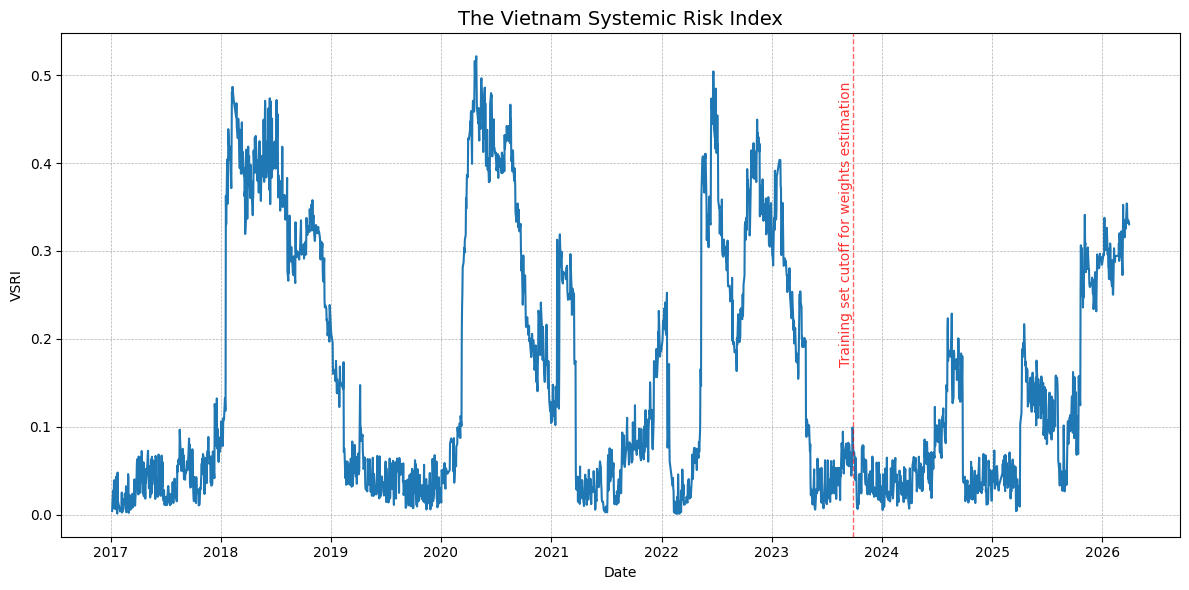

In [83]:
fig, ax1 = plt.subplots(figsize=(12, 6))
#plt.plot(vsri.rolling(10).mean())
plt.plot(vsri)
#plt.plot(vn_stress.loc['2017-01-01':])
#plt.plot(vn_vol.loc['2017-01-01':])
plt.title('The Vietnam Systemic Risk Index', fontsize=14)
plt.xlabel('Date')
plt.ylabel('VSRI')
plt.grid(True, linestyle='--', linewidth=.5)
cutoff_date = vsri.loc[:"2024-03-31"].iloc[:int(-purge/2)].index[-1]
plt.axvline(cutoff_date, color='red', linestyle='--', linewidth=1, alpha=0.6)
plt.text(cutoff_date, plt.ylim()[1]*0.9, 'Training set cutoff for weights estimation',
         rotation=90, color='red', va='top', ha='right', alpha=0.8)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
#plt.ylim([-0.05, 0.75])
plt.show()

## 5. Predicting Financial Stress Events with Machine Learning

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import recall_score, f1_score, roc_auc_score, confusion_matrix, accuracy_score, roc_curve
import itertools

In [85]:
# Build a Systemic Stress Events variable:
# Parameters
ret_window = 20     # horizon for future cumulative log returns
quant_window = 250 # rolling window for empirical distribution
# 20-day ahead cumulative log returns (log returns are additive)
cum_log_ret_20dahead = (df_glob_ret["VNINDEX"].rolling(20).sum().shift(-20))
# Rolling 5th percentile (based only on past information)
rolling_q05 = cum_log_ret_20dahead.rolling(quant_window).quantile(0.05)
# Systemic Stress Events (1 if current return is below its rolling threshold)
sse = (cum_log_ret_20dahead <= rolling_q05).astype(int)

df_sse = pd.DataFrame({"cum_log_ret_20d": cum_log_ret_20dahead, "q05_rolling_250d": rolling_q05, "systemic_stress_event": sse})

In [86]:
# build a dataframe with the VSRI (predictor) and the Systemic Stress Events variable (target)
df_model = pd.concat([vsri, df_sse['systemic_stress_event']], axis=1, join='inner').dropna()
# split data in training and test set and apply purging
split_date = "2024-03-31"
purge = 250
train = df_model.loc[:split_date].iloc[:int(-purge/2)]
test  = df_model.loc[split_date:].iloc[int(purge/2):]
X_train = train[["VSRI"]]
y_train = train["systemic_stress_event"]
X_test  = test[["VSRI"]]
y_test  = test["systemic_stress_event"]

In [87]:
X_train.shape, y_train.shape

((1681, 1), (1681,))

In [88]:
X_test.shape, y_test.shape

((371, 1), (371,))

In [89]:
df_model.groupby('systemic_stress_event').nunique()

,VSRI
systemic_stress_event,
0,2150
1,152


In [90]:
test.groupby('systemic_stress_event').nunique()

,VSRI
systemic_stress_event,
0,347
1,24


In [91]:
def train_classifier(model, X_train, y_train, X_test, y_test, class_weight=None):
  if class_weight is not None:
    if hasattr(model, "class_weight"):
      model.set_params(class_weight=class_weight)

  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  # Probabilities (for ROC-AUC)
  #if hasattr(model, "predict_proba"):
  y_score = model.predict_proba(X_test)[:, 1]
  #else:
    # fallback for models like SVM
    #y_score = model.decision_function(X_test)

  # Output Following Metrics:
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  roc_auc = roc_auc_score(y_test, y_score)
  cm = confusion_matrix(y_test, y_pred)
  return recall, f1, roc_auc, cm, y_score

### 4.1. Logistic Regression.

In [92]:
model = LogisticRegression(class_weight="balanced")
lr_results = train_classifier(model, X_train, y_train, X_test, y_test, class_weight=None)

In [93]:
lr_recall, lr_f1, lr_roc_auc, lr_cm, lr_probs = lr_results

In [94]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("Normalized confusion matrix")
  else:
    print('Confusion matrix, without normalization')

  print(cm)
  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes)#, rotation=45)
  plt.yticks(tick_marks, classes)
  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')

Confusion matrix, without normalization
[[114 233]
 [  6  18]]


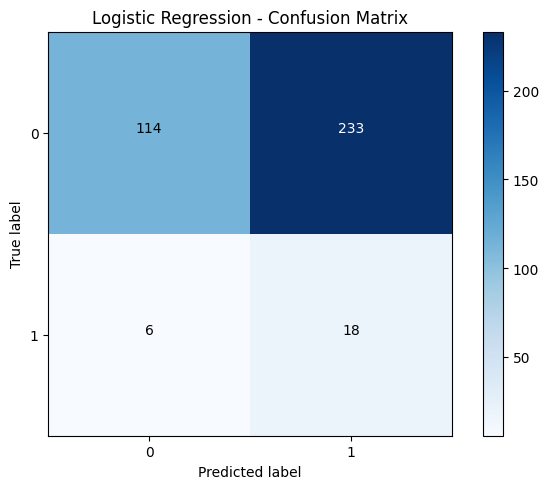

In [95]:
#Plot confusion matrix
plt.figure()
plot_confusion_matrix(cm=lr_cm, classes=[0,1], normalize= False,  title='Logistic Regression - Confusion Matrix')

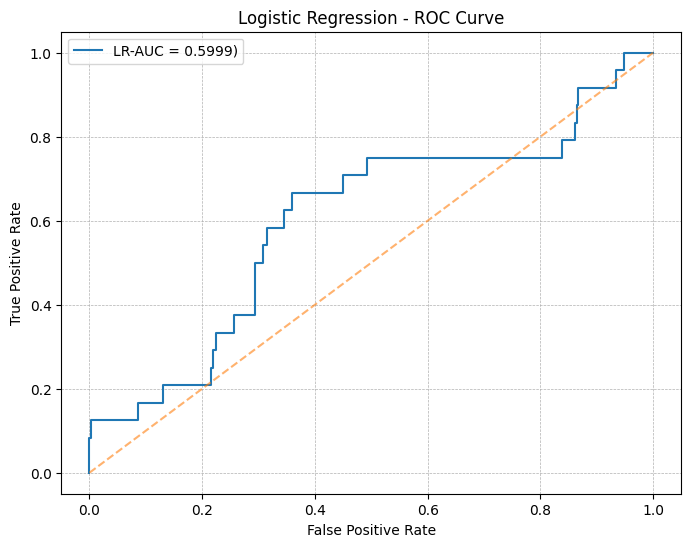

In [96]:
fpr, tpr, thr = roc_curve(y_test, lr_probs)
# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"LR-AUC = {lr_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")
plt.legend()
plt.grid(True, linestyle='--', linewidth=.5)
plt.show()

In [97]:
ml_results = {'Recall': lr_recall, 'F1-Score': lr_f1, 'ROC-AUC': lr_roc_auc}
ml_results = pd.DataFrame(ml_results, index=['Logistc Regression'])
ml_results

,Recall,F1-Score,ROC-AUC
Logistc Regression,0.75,0.130909,0.599904


### 4.2. Support Vector Machines.

In [98]:
model = SVC(C=1.0, kernel='rbf', probability=True, class_weight="balanced")
svm_results = train_classifier(model, X_train, y_train, X_test, y_test, class_weight=None)

In [99]:
svm_recall, svm_f1, svm_roc_auc, svm_cm, svm_probs = svm_results

Confusion matrix, without normalization
[[ 99 248]
 [  6  18]]


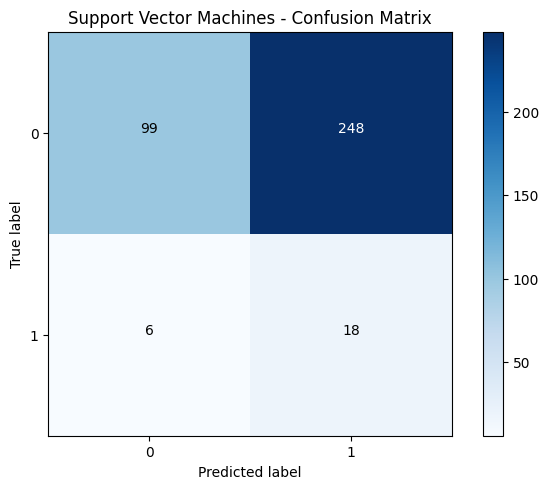

In [100]:
#Plot confusion matrix
plt.figure()
plot_confusion_matrix(cm=svm_cm, classes=[0,1], normalize= False,  title='Support Vector Machines - Confusion Matrix')

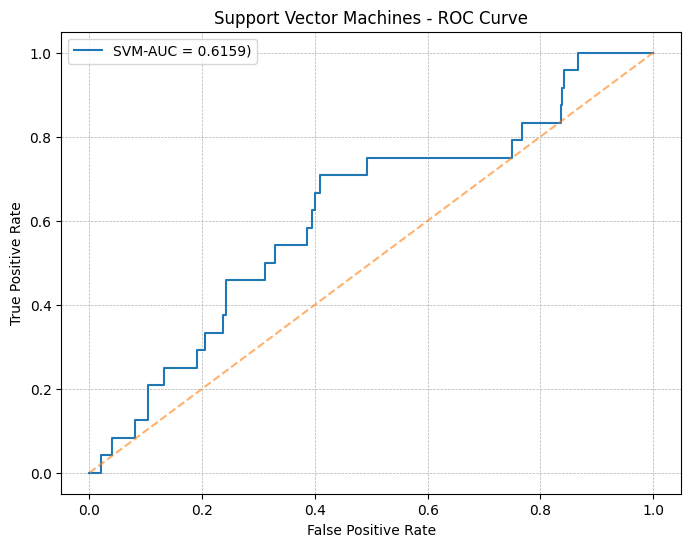

In [101]:
fpr, tpr, thr = roc_curve(y_test, svm_probs)
# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"SVM-AUC = {svm_roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Support Vector Machines - ROC Curve")
plt.legend()
plt.grid(True, linestyle='--', linewidth=.5)
plt.show()

In [102]:
svm_results_df = pd.DataFrame({'Recall': svm_recall, 'F1-Score': svm_f1, 'ROC-AUC': svm_roc_auc},index=['Support Vector Machines'])
ml_results = pd.concat([ml_results, svm_results_df])
ml_results

,Recall,F1-Score,ROC-AUC
Logistc Regression,0.75,0.130909,0.599904
Support Vector Machines,0.75,0.124138,0.615874


### 4.3. Long Short-Term Memory (LSTM) Networks.

In [103]:
timesteps = 20
X_train_values = X_train.values
y_train_values = y_train.values
X_test_values = X_train.values
y_test_values = y_train.values
X_train_seq = []
y_train_seq = []
X_test_seq = []
y_test_seq = []
for i in range(timesteps, len(X_train_values)):
  X_train_seq.append(X_train_values[i - timesteps:i])
  y_train_seq.append(y_train_values[i])
  X_test_seq.append(X_test_values[i - timesteps:i])
  y_test_seq.append(y_train_values[i])

X_train_seq = np.array(X_train_seq)
y_train_seq = np.array(y_train_seq)
X_test_seq = np.array(X_test_seq)
y_test_seq = np.array(y_test_seq)

In [104]:
model = Sequential()
model.add(LSTM(units=64,return_sequences=True, input_shape=(timesteps, 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=32,return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(16, activation="relu"))
# Binary classification output
model.add(Dense(1, activation="sigmoid"))
model.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=[
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.AUC(name="auc")])

In [105]:
history = model.fit(X_train_seq, y_train_seq, epochs=20, batch_size=32, validation_data=(X_test_seq, y_test_seq), shuffle=False)

Epoch 1/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - auc: 0.4766 - loss: 0.3944 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_auc: 0.5683 - val_loss: 0.2625 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - auc: 0.4666 - loss: 0.2706 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_auc: 0.5495 - val_loss: 0.2635 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - auc: 0.4487 - loss: 0.2712 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_auc: 0.5670 - val_loss: 0.2637 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - auc: 0.4498 - loss: 0.2706 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_auc: 0.5578 - val_loss: 0.2638 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/20
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - auc: 0.4663 - loss: 0.2689 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_auc: 0.56